# Spatio-Temporal PM2.5 Forecasting Using Machine Learning, CNN-LSTM and OpenAQ Data

## Final Kaggle-ready notebook

This notebook builds a reproducible end-to-end PM2.5 **next-available-reading forecasting** workflow using secondary OpenAQ ground-monitoring data.

Key methodological safeguards in this final version:

- future-derived `forecast_gap_hours` is retained only for audit/filtering and **excluded from predictors**;
- train, validation and test sets are separated by **timestamp cut-offs**, so identical timestamps are not split across partitions;
- high-cardinality category groupings are learned from the **training split only**;
- the final conventional ML model is selected **only on validation RMSE**;
- after selection, the chosen model is refitted on train + validation data and evaluated **once** on the held-out test set;
- CNN-LSTM sequences use the same temporal cut-offs and contain only information available up to the prediction origin;
- the conventional ML model and CNN-LSTM are additionally compared on an **identical common test subset**;
- important Matplotlib figures are automatically exported to the project output folder.

> **Forecast definition:** predict the next available PM2.5 reading at a station. The observed gap to that next reading is allowed to be greater than 0 and at most 72 hours, but the gap itself is never used as a model feature.


In [146]:
# Notebook configuration
# Run this notebook on Kaggle after attaching a CSV dataset containing OpenAQ data.
# Recommended filename: openaq_global_air_quality_filtered.csv
# If BigQuery integration is enabled, the notebook can also query the public OpenAQ BigQuery table as a fallback.

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

@dataclass(frozen=True)
class ProjectConfig:
    project_name: str = "OpenAQ Spatio-Temporal PM2.5 Forecasting"
    output_dir: str = "/kaggle/working/openaq_project_outputs"
    random_seed: int = 42
    target_pollutant: str = "pm25"

    # Modelling controls
    modelling_sample_limit: int = 90_000
    minimum_station_records: int = 30
    maximum_forecast_gap_hours: float = 72.0

    # Training-only category grouping controls
    top_country_categories: int = 10
    top_city_categories: int = 60
    top_source_categories: int = 30

    # Deep-learning controls
    sequence_length: int = 12
    deep_learning_sample_limit: int = 90_000
    enable_deep_learning: bool = True
    enable_shap: bool = True

    # BigQuery settings are optional. They are used only if no CSV file is found and Kaggle BigQuery is enabled.
    bigquery_project: str = "bigquery-public-data"
    bigquery_dataset: str = "openaq"
    bigquery_table: str = "global_air_quality"
    max_raw_rows: int = 500_000
    max_gb_scanned: float = 5.0

config = ProjectConfig()
Path(config.output_dir).mkdir(parents=True, exist_ok=True)
print(config)


ProjectConfig(project_name='OpenAQ Spatio-Temporal PM2.5 Forecasting', output_dir='/kaggle/working/openaq_project_outputs', random_seed=42, target_pollutant='pm25', modelling_sample_limit=90000, minimum_station_records=30, maximum_forecast_gap_hours=72.0, top_country_categories=10, top_city_categories=60, top_source_categories=30, sequence_length=12, deep_learning_sample_limit=90000, enable_deep_learning=True, enable_shap=True, bigquery_project='bigquery-public-data', bigquery_dataset='openaq', bigquery_table='global_air_quality', max_raw_rows=500000, max_gb_scanned=5.0)


## 1. Import libraries

The notebook uses standard data science libraries available in Kaggle. Optional libraries such as Plotly, Folium, XGBoost, TensorFlow and SHAP are used only when available.

In [147]:
import os
import math
import json
import re
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

FIGURE_DIR = Path(config.output_dir) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
_FIGURE_COUNTER = 0


def show_and_save_figure(filename_stem: Optional[str] = None, dpi: int = 180) -> None:
    """Save the current Matplotlib figure with a unique professional filename, then display it."""
    global _FIGURE_COUNTER
    _FIGURE_COUNTER += 1
    figure = plt.gcf()

    if filename_stem is None:
        detected_title = ""
        if figure.axes:
            detected_title = str(figure.axes[0].get_title()).strip()
        filename_stem = detected_title or "figure"

    safe_stem = re.sub(r"[^A-Za-z0-9_-]+", "_", filename_stem).strip("_")[:90] or "figure"
    figure_path = FIGURE_DIR / f"{_FIGURE_COUNTER:02d}_{safe_stem}.png"
    figure.savefig(figure_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {figure_path}")


try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception as plotly_error:
    PLOTLY_AVAILABLE = False
    print(f"Plotly unavailable: {plotly_error}")

try:
    import folium
    from folium.plugins import MarkerCluster
    FOLIUM_AVAILABLE = True
except Exception as folium_error:
    FOLIUM_AVAILABLE = False
    print(f"Folium unavailable: {folium_error}")

try:
    import joblib
    JOBLIB_AVAILABLE = True
except Exception as joblib_error:
    JOBLIB_AVAILABLE = False
    print(f"Joblib unavailable: {joblib_error}")

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as xgboost_error:
    XGBOOST_AVAILABLE = False
    print(f"XGBoost unavailable: {xgboost_error}")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
    keras.utils.set_random_seed(config.random_seed)
except Exception as tensorflow_error:
    TENSORFLOW_AVAILABLE = False
    print(f"TensorFlow unavailable: {tensorflow_error}")

np.random.seed(config.random_seed)
print("Libraries imported successfully")


Libraries imported successfully


## 2. Load OpenAQ dataset

This notebook uses a CSV-first loading strategy because the current Kaggle error shows that BigQuery authentication is not enabled and `/kaggle/input` is empty. The reliable method is:

1. Download `openaq_global_air_quality_filtered.csv` or the ZIP version provided with this work.
2. Create a Kaggle Dataset from that CSV/ZIP.
3. Add that Kaggle Dataset to this notebook using **Add Data**.
4. Run the notebook.

The loader automatically searches under `/kaggle/input` for CSV or ZIP files that contain the OpenAQ columns. If no file is found, it tries BigQuery only as an optional fallback.


In [148]:
# Optional BigQuery import. The notebook does not require this when a CSV dataset is attached.
try:
    from google.cloud import bigquery
    BIGQUERY_CLIENT_AVAILABLE = True
    print("google.cloud.bigquery is available")
except Exception as bigquery_error:
    BIGQUERY_CLIENT_AVAILABLE = False
    print(f"google.cloud.bigquery unavailable: {bigquery_error}")


google.cloud.bigquery is available


In [149]:
def create_bigquery_client():
    """Create a BigQuery client using Kaggle credentials, if BigQuery is enabled."""
    if not BIGQUERY_CLIENT_AVAILABLE:
        raise RuntimeError("google.cloud.bigquery is not available in this notebook environment.")
    return bigquery.Client()


## 3. Prepare a research-ready OpenAQ sample

The expected raw columns are: `location`, `city`, `country`, `pollutant`, `value`, `timestamp`, `unit`, `source_name`, `latitude`, `longitude`, and `averaged_over_in_hours`.

The loader accepts a full or filtered OpenAQ CSV. If the CSV has additional columns, they will be ignored later when required.


In [150]:
def standardise_column_names(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with lower-case snake-style column names."""
    renamed_columns = {
        column_name: str(column_name).strip().lower().replace(" ", "_")
        for column_name in dataframe.columns
    }
    return dataframe.rename(columns=renamed_columns).copy()


def has_required_openaq_columns(dataframe: pd.DataFrame) -> bool:
    """Check whether a dataframe contains the minimum OpenAQ fields required for this project."""
    required_columns = {
        "location",
        "city",
        "country",
        "pollutant",
        "value",
        "timestamp",
        "unit",
        "source_name",
        "latitude",
        "longitude",
        "averaged_over_in_hours",
    }
    available_columns = set(standardise_column_names(dataframe).columns)
    return required_columns.issubset(available_columns)


def preview_csv_candidate(file_path: Path, row_limit: int = 50) -> Optional[pd.DataFrame]:
    """Try to read a small preview from a CSV or ZIP candidate."""
    try:
        return pd.read_csv(file_path, nrows=row_limit)
    except Exception:
        return None


def discover_local_openaq_files() -> List[Path]:
    """Find likely OpenAQ CSV or ZIP files attached to the Kaggle notebook."""
    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("/mnt/data"),
    ]

    candidate_files = []
    for search_root in search_roots:
        if not search_root.exists():
            continue
        candidate_files.extend(search_root.rglob("*.csv"))
        candidate_files.extend(search_root.rglob("*.csv.gz"))
        candidate_files.extend(search_root.rglob("*.zip"))

    ranked_candidates = []
    for candidate_file in candidate_files:
        lower_name = candidate_file.name.lower()
        lower_path = str(candidate_file).lower()
        name_score = 0
        if "openaq" in lower_path:
            name_score += 10
        if "global_air_quality" in lower_path:
            name_score += 8
        if "air_quality" in lower_path:
            name_score += 5
        if lower_name.endswith(".csv"):
            name_score += 3
        if lower_name.endswith(".zip"):
            name_score += 1
        ranked_candidates.append((name_score, candidate_file))

    ranked_candidates.sort(key=lambda item: (-item[0], str(item[1])))
    return [candidate_file for _, candidate_file in ranked_candidates]


def load_local_openaq_csv() -> Optional[pd.DataFrame]:
    """Load the first attached CSV/ZIP file that matches the expected OpenAQ schema."""
    candidate_files = discover_local_openaq_files()
    print(f"Local CSV/ZIP candidates found: {len(candidate_files)}")

    for candidate_file in candidate_files[:50]:
        print(f"Checking candidate: {candidate_file}")
        preview_dataframe = preview_csv_candidate(candidate_file)
        if preview_dataframe is None:
            print("  Skipped: could not read preview")
            continue
        if has_required_openaq_columns(preview_dataframe):
            print(f"Loading OpenAQ data from local file: {candidate_file}")
            return standardise_column_names(pd.read_csv(candidate_file))
        print("  Skipped: required OpenAQ columns were not found")

    return None


def build_openaq_query(project_config: ProjectConfig) -> str:
    """Create a controlled SQL query for the OpenAQ public BigQuery table."""
    table_id = f"{project_config.bigquery_project}.{project_config.bigquery_dataset}.{project_config.bigquery_table}"
    return f"""
        SELECT
            location,
            city,
            country,
            pollutant,
            value,
            timestamp,
            unit,
            source_name,
            latitude,
            longitude,
            averaged_over_in_hours
        FROM `{table_id}`
        WHERE pollutant IN ('pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'bc')
          AND country IN ('IN', 'GB', 'US', 'CN')
          AND value IS NOT NULL
          AND timestamp IS NOT NULL
          AND latitude IS NOT NULL
          AND longitude IS NOT NULL
        ORDER BY timestamp
        LIMIT {project_config.max_raw_rows}
    """


def query_with_google_bigquery(sql_query: str, project_config: ProjectConfig) -> pd.DataFrame:
    """Query OpenAQ using the official BigQuery client when Kaggle BigQuery is enabled."""
    client = create_bigquery_client()
    maximum_bytes = int(project_config.max_gb_scanned * (1024 ** 3))
    job_config = bigquery.QueryJobConfig(
        use_legacy_sql=False,
        maximum_bytes_billed=maximum_bytes,
    )
    query_job = client.query(sql_query, job_config=job_config)
    return query_job.result().to_dataframe(create_bqstorage_client=False)


def print_kaggle_input_debugging_summary() -> None:
    """Print useful debugging information when no attached dataset is found."""
    input_root = Path("/kaggle/input")
    print("Kaggle input debugging summary")
    print(f"/kaggle/input exists: {input_root.exists()}")
    if input_root.exists():
        all_paths = sorted(input_root.rglob("*"))
        print(f"Number of files/folders under /kaggle/input: {len(all_paths)}")
        for path in all_paths[:300]:
            print(path)


def load_openaq_data(project_config: ProjectConfig) -> pd.DataFrame:
    """Load OpenAQ data from an attached CSV first, then BigQuery as an optional fallback."""
    cached_csv_path = Path(project_config.output_dir) / "openaq_raw_sample.csv"
    if cached_csv_path.exists():
        print(f"Loading cached data from {cached_csv_path}")
        return standardise_column_names(pd.read_csv(cached_csv_path))

    local_dataframe = load_local_openaq_csv()
    if local_dataframe is not None:
        local_dataframe.to_csv(cached_csv_path, index=False)
        print(f"Saved local data cache to {cached_csv_path}")
        return local_dataframe

    print("No usable local CSV/ZIP was found. Trying BigQuery as fallback.")
    try:
        sql_query = build_openaq_query(project_config)
        dataframe = standardise_column_names(query_with_google_bigquery(sql_query, project_config))
        dataframe.to_csv(cached_csv_path, index=False)
        print(f"Saved BigQuery result to {cached_csv_path}")
        return dataframe
    except Exception as query_error:
        print(f"BigQuery fallback failed: {query_error}")
        print_kaggle_input_debugging_summary()

    raise RuntimeError(
        "OpenAQ data could not be loaded. Your Kaggle session has no attached CSV dataset and BigQuery is not authorised. "
        "Fix: upload openaq_global_air_quality_filtered.csv as a Kaggle Dataset, attach it using Add Data, then restart and run all."
    )


raw_air_quality_df = load_openaq_data(config)
print(f"Raw dataset shape: {raw_air_quality_df.shape}")
display(raw_air_quality_df.head())


Loading cached data from /kaggle/working/openaq_project_outputs/openaq_raw_sample.csv
Raw dataset shape: (500000, 11)


,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours
0,SPARTAN - Emory University,Atlanta,US,pm25,5.0,2014-03-13 12:00:00+00:00,µg/m³,Spartan,33.688,-84.290,1.000
1,SPARTAN - Emory University,Atlanta,US,pm25,5.0,2014-03-13 12:00:00+00:00,µg/m³,Spartan,1.000,33.688,-84.290
2,SPARTAN - Mammoth Cave,Mammoth Cave NP,US,pm25,7.1,2014-08-12 20:00:00+00:00,µg/m³,Spartan,37.132,-86.148,1.000
3,SPARTAN - Mammoth Cave,Mammoth Cave NP,US,pm25,7.1,2014-08-12 20:00:00+00:00,µg/m³,Spartan,1.000,37.132,-86.148
4,SPARTAN - IIT Kanpur,Kanpur,IN,pm25,27.8,2014-09-26 00:30:00+00:00,µg/m³,Spartan,26.519,80.233,1.000


## 4. Initial data audit

This section audits dataset structure, missing values, duplicates, units, countries, pollutants and temporal coverage before any modelling decisions are made.

In [151]:

def create_dataset_audit_table(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Create a compact audit table for the dataset."""
    audit_rows = []
    for column_name in dataframe.columns:
        audit_rows.append({
            "column": column_name,
            "dtype": str(dataframe[column_name].dtype),
            "non_null_count": int(dataframe[column_name].notna().sum()),
            "missing_count": int(dataframe[column_name].isna().sum()),
            "missing_percent": round(float(dataframe[column_name].isna().mean() * 100), 3),
            "unique_count": int(dataframe[column_name].nunique(dropna=True)),
            "sample_values": dataframe[column_name].dropna().astype(str).head(3).tolist(),
        })
    return pd.DataFrame(audit_rows)

initial_audit_df = create_dataset_audit_table(raw_air_quality_df)
display(initial_audit_df)

print(f"Duplicate rows: {raw_air_quality_df.duplicated().sum():,}")
print(f"Memory usage: {raw_air_quality_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

,column,dtype,non_null_count,missing_count,missing_percent,unique_count,sample_values
0,location,object,499900,100,0.020,4875,"[SPARTAN - Emory University, SPARTAN - Emory U..."
1,city,object,499472,528,0.106,1631,"[Atlanta, Atlanta, Mammoth Cave NP]"
2,country,object,500000,0,0.000,4,"[US, US, US]"
3,pollutant,object,500000,0,0.000,7,"[pm25, pm25, pm25]"
4,value,float64,500000,0,0.000,18350,"[5.0, 5.0, 7.1]"
5,timestamp,object,500000,0,0.000,3749,"[2014-03-13 12:00:00+00:00, 2014-03-13 12:00:0..."
6,unit,object,500000,0,0.000,2,"[µg/m³, µg/m³, µg/m³]"
7,source_name,object,500000,0,0.000,35,"[Spartan, Spartan, Spartan]"
8,latitude,float64,500000,0,0.000,2575,"[33.688, 1.0, 37.132]"
9,longitude,float64,500000,0,0.000,7976,"[-84.29, 33.688, -86.148]"


Duplicate rows: 0
Memory usage: 221.06 MB


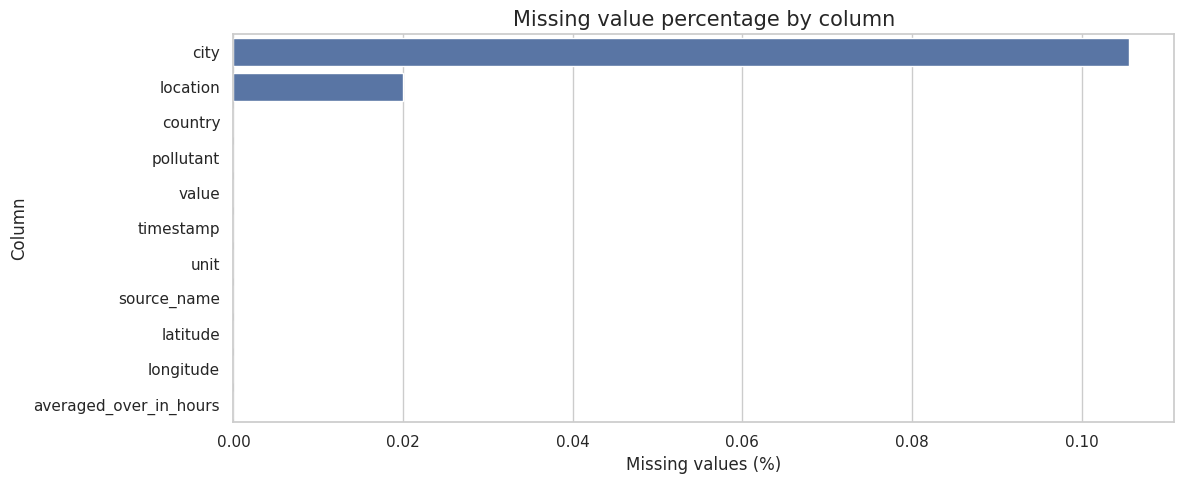

Figure saved to /kaggle/working/openaq_project_outputs/figures/01_Missing_value_percentage_by_column.png


In [152]:

def plot_missing_value_profile(dataframe: pd.DataFrame, title: str) -> None:
    """Plot missing value percentages by column."""
    missing_percentages = (
        dataframe.isna().mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index()
    )
    missing_percentages.columns = ["column", "missing_percent"]

    plt.figure(figsize=(12, 5))
    sns.barplot(data=missing_percentages, x="missing_percent", y="column")
    plt.title(title)
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    show_and_save_figure()
plot_missing_value_profile(raw_air_quality_df, "Missing value percentage by column")

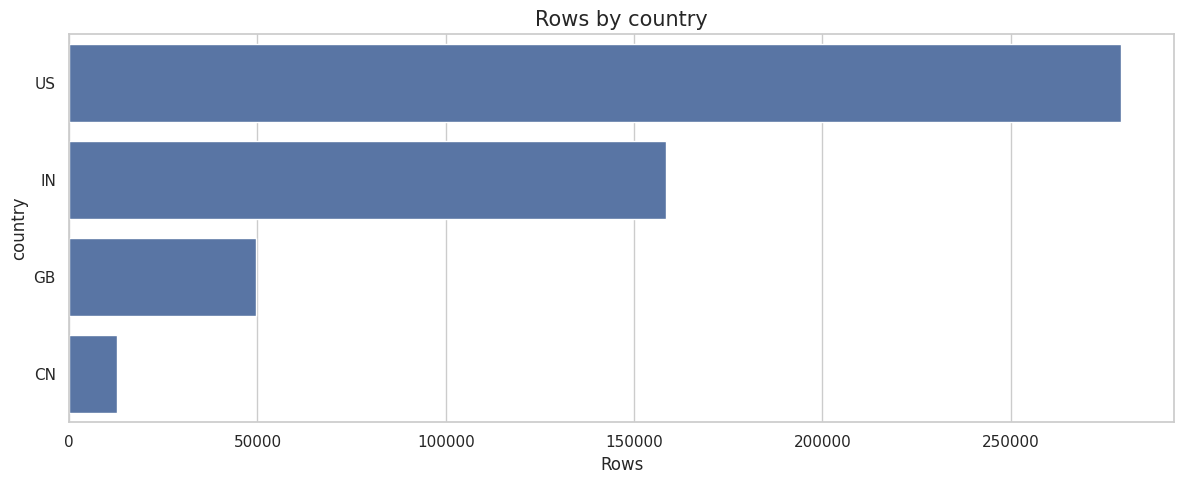

Figure saved to /kaggle/working/openaq_project_outputs/figures/02_Rows_by_country.png


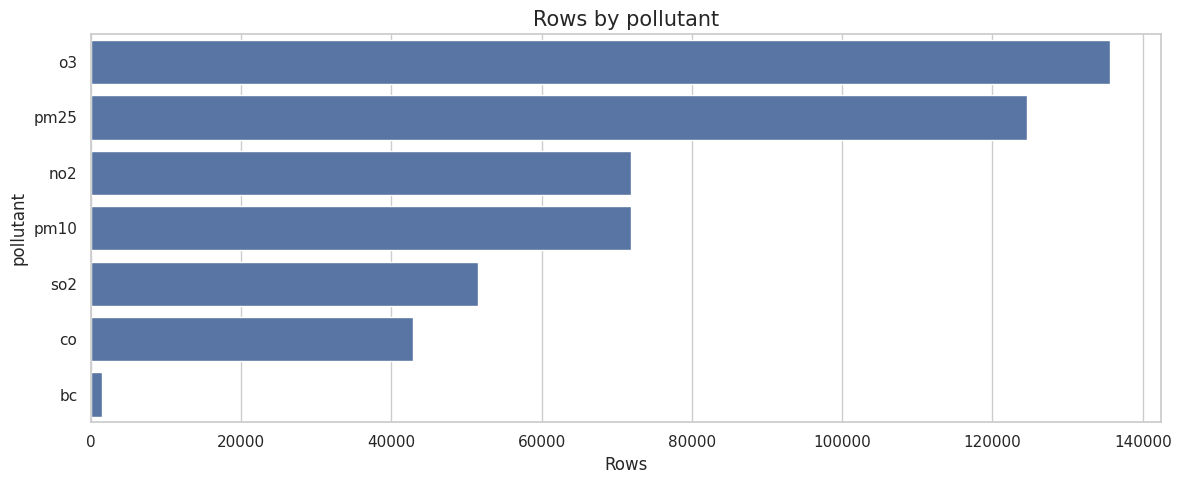

Figure saved to /kaggle/working/openaq_project_outputs/figures/03_Rows_by_pollutant.png


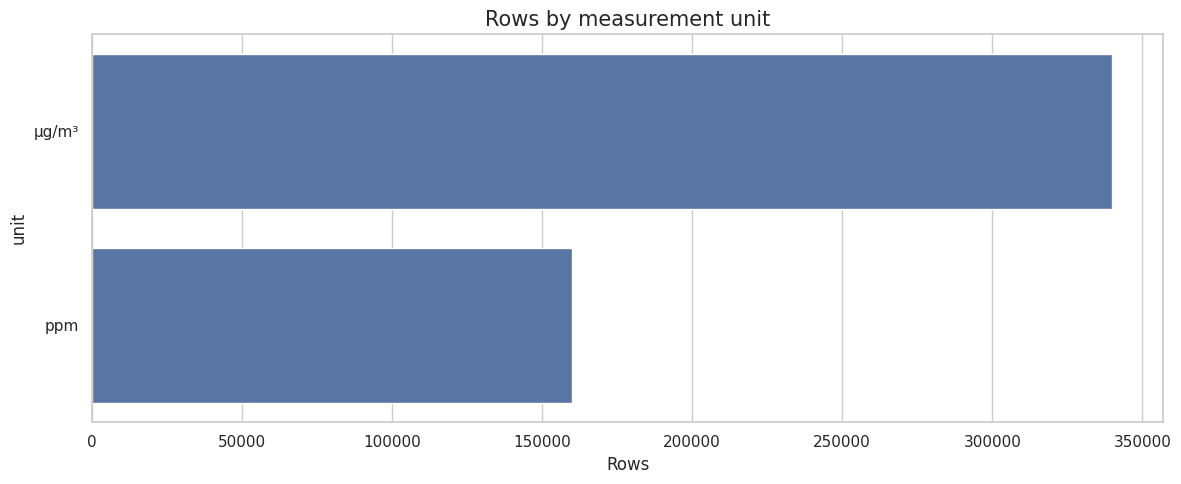

Figure saved to /kaggle/working/openaq_project_outputs/figures/04_Rows_by_measurement_unit.png


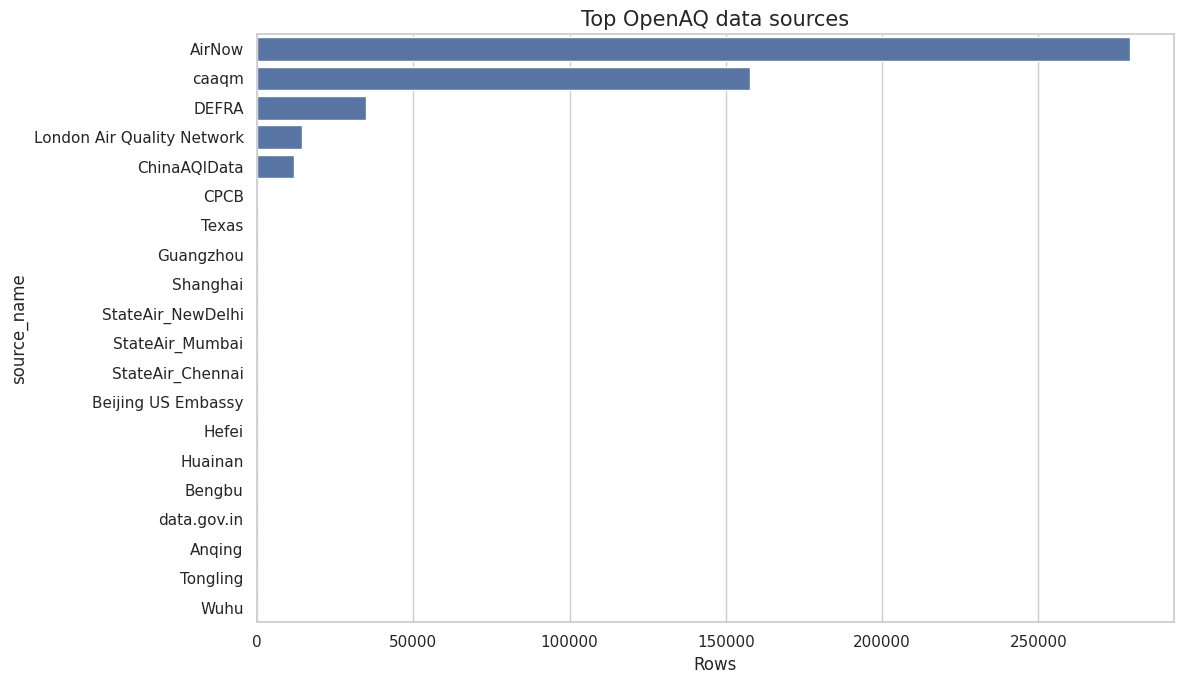

Figure saved to /kaggle/working/openaq_project_outputs/figures/05_Top_OpenAQ_data_sources.png


In [153]:

def plot_top_category_counts(dataframe: pd.DataFrame, column_name: str, title: str, top_n: int = 20) -> None:
    """Plot top category counts for a selected column."""
    category_counts = (
        dataframe[column_name]
        .astype("string")
        .fillna("Unknown")
        .value_counts()
        .head(top_n)
        .reset_index()
    )
    category_counts.columns = [column_name, "row_count"]

    plt.figure(figsize=(12, max(5, top_n * 0.35)))
    sns.barplot(data=category_counts, x="row_count", y=column_name)
    plt.title(title)
    plt.xlabel("Rows")
    plt.ylabel(column_name)
    plt.tight_layout()
    show_and_save_figure()
plot_top_category_counts(raw_air_quality_df, "country", "Rows by country", top_n=10)
plot_top_category_counts(raw_air_quality_df, "pollutant", "Rows by pollutant", top_n=10)
plot_top_category_counts(raw_air_quality_df, "unit", "Rows by measurement unit", top_n=10)
plot_top_category_counts(raw_air_quality_df, "source_name", "Top OpenAQ data sources", top_n=20)

## 5. Data preparation and cleaning

The cleaning process standardises names, converts timestamps, validates coordinates, removes invalid pollutant values, and keeps clear provenance fields. A coordinate-repair function is included because some exported CSV versions may contain shifted numeric columns.

In [154]:
COUNTRY_BOUNDING_BOXES: Dict[str, Tuple[float, float, float, float]] = {
    "IN": (6.0, 37.5, 68.0, 98.5),
    "GB": (49.0, 61.5, -9.0, 2.5),
    "US": (18.0, 72.0, -170.0, -50.0),
    "CN": (18.0, 54.5, 73.0, 135.5),
}


def coordinates_within_country_bounds(
    country_series: pd.Series,
    latitude_series: pd.Series,
    longitude_series: pd.Series,
) -> pd.Series:
    """Vectorised plausibility check for country-specific coordinate bounds."""
    country_codes = country_series.astype("string").str.upper()
    valid_mask = pd.Series(False, index=country_series.index)

    for country_code, bounds in COUNTRY_BOUNDING_BOXES.items():
        min_lat, max_lat, min_lon, max_lon = bounds
        country_mask = country_codes.eq(country_code)
        valid_mask |= (
            country_mask
            & latitude_series.between(min_lat, max_lat)
            & longitude_series.between(min_lon, max_lon)
        )

    other_country_mask = ~country_codes.isin(COUNTRY_BOUNDING_BOXES.keys())
    valid_mask |= (
        other_country_mask
        & latitude_series.between(-90, 90)
        & longitude_series.between(-180, 180)
    )
    return valid_mask.fillna(False)


def repair_shifted_coordinate_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Repair shifted coordinate columns sometimes created by CSV exports, using vectorised operations."""
    repaired_df = dataframe.copy()
    required_columns = {"country", "latitude", "longitude", "averaged_over_in_hours"}
    if not required_columns.issubset(repaired_df.columns):
        return repaired_df

    repaired_df["latitude"] = pd.to_numeric(repaired_df["latitude"], errors="coerce")
    repaired_df["longitude"] = pd.to_numeric(repaired_df["longitude"], errors="coerce")
    repaired_df["averaged_over_in_hours"] = pd.to_numeric(
        repaired_df["averaged_over_in_hours"], errors="coerce"
    )

    original_latitude = repaired_df["latitude"].copy()
    original_longitude = repaired_df["longitude"].copy()
    original_average_hours = repaired_df["averaged_over_in_hours"].copy()

    already_valid_mask = coordinates_within_country_bounds(
        repaired_df["country"], original_latitude, original_longitude
    )
    shifted_valid_mask = coordinates_within_country_bounds(
        repaired_df["country"], original_longitude, original_average_hours
    )
    repair_mask = (~already_valid_mask) & shifted_valid_mask

    repaired_df.loc[repair_mask, "averaged_over_in_hours"] = original_latitude.loc[repair_mask]
    repaired_df.loc[repair_mask, "latitude"] = original_longitude.loc[repair_mask]
    repaired_df.loc[repair_mask, "longitude"] = original_average_hours.loc[repair_mask]

    repaired_df["coordinate_status"] = np.select(
        [already_valid_mask, repair_mask],
        ["valid", "repaired_shift"],
        default="invalid",
    )

    print(f"Coordinate rows repaired: {int(repair_mask.sum()):,}")
    print(repaired_df["coordinate_status"].value_counts(dropna=False))
    return repaired_df


def clean_openaq_dataframe(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Clean OpenAQ rows for exploratory analysis and modelling."""
    cleaned_df = dataframe.copy()

    expected_columns = [
        "location", "city", "country", "pollutant", "value", "timestamp", "unit",
        "source_name", "latitude", "longitude", "averaged_over_in_hours",
    ]
    missing_columns = [column for column in expected_columns if column not in cleaned_df.columns]
    if missing_columns:
        raise ValueError(f"Missing expected columns: {missing_columns}")

    text_columns = ["location", "city", "country", "pollutant", "unit", "source_name"]
    for column_name in text_columns:
        cleaned_df[column_name] = cleaned_df[column_name].astype("string").str.strip()

    cleaned_df["country"] = cleaned_df["country"].str.upper()
    cleaned_df["pollutant"] = cleaned_df["pollutant"].str.lower()
    cleaned_df["timestamp"] = pd.to_datetime(cleaned_df["timestamp"], errors="coerce", utc=True)
    cleaned_df["value"] = pd.to_numeric(cleaned_df["value"], errors="coerce")
    cleaned_df["latitude"] = pd.to_numeric(cleaned_df["latitude"], errors="coerce")
    cleaned_df["longitude"] = pd.to_numeric(cleaned_df["longitude"], errors="coerce")
    cleaned_df["averaged_over_in_hours"] = pd.to_numeric(cleaned_df["averaged_over_in_hours"], errors="coerce")

    cleaned_df = repair_shifted_coordinate_columns(cleaned_df)

    before_rows = len(cleaned_df)
    cleaned_df = cleaned_df.drop_duplicates()
    cleaned_df = cleaned_df.dropna(subset=["country", "pollutant", "value", "timestamp", "latitude", "longitude"])
    cleaned_df = cleaned_df[cleaned_df["coordinate_status"].ne("invalid")]
    cleaned_df = cleaned_df[cleaned_df["latitude"].between(-90, 90)]
    cleaned_df = cleaned_df[cleaned_df["longitude"].between(-180, 180)]
    cleaned_df = cleaned_df[cleaned_df["value"].ge(0)]
    cleaned_df = cleaned_df[~cleaned_df["value"].isin([9999, 99999])]

    cleaned_df["location"] = cleaned_df["location"].fillna("Unknown location")
    cleaned_df["city"] = cleaned_df["city"].fillna("Unknown city")
    cleaned_df["source_name"] = cleaned_df["source_name"].fillna("Unknown source")

    cleaned_df["station_id"] = (
        cleaned_df["country"].astype(str) + "_" +
        cleaned_df["city"].astype(str) + "_" +
        cleaned_df["location"].astype(str) + "_" +
        cleaned_df["latitude"].round(3).astype(str) + "_" +
        cleaned_df["longitude"].round(3).astype(str)
    )

    cleaned_df = cleaned_df.sort_values(["station_id", "pollutant", "timestamp"]).reset_index(drop=True)
    after_rows = len(cleaned_df)
    print(f"Rows before cleaning: {before_rows:,}")
    print(f"Rows after cleaning: {after_rows:,}")
    print(f"Rows removed: {before_rows - after_rows:,}")
    return cleaned_df

clean_air_quality_df = clean_openaq_dataframe(raw_air_quality_df)
clean_csv_path = Path(config.output_dir) / "openaq_clean_sensor_data.csv"
clean_air_quality_df.to_csv(clean_csv_path, index=False)
print(f"Clean dataset saved to {clean_csv_path}")
display(clean_air_quality_df.head())


Coordinate rows repaired: 493,612
coordinate_status
repaired_shift    493612
valid               6096
invalid              292
Name: count, dtype: int64
Rows before cleaning: 500,000
Rows after cleaning: 496,886
Rows removed: 3,114
Clean dataset saved to /kaggle/working/openaq_project_outputs/openaq_clean_sensor_data.csv


,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,coordinate_status,station_id
0,Anqing An Qing Da Xue,Anqing,CN,co,805.0,2018-10-13 21:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,valid,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989
1,Anqing An Qing Da Xue,Anqing,CN,co,300.0,2019-12-27 09:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,repaired_shift,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989
2,Anqing An Qing Da Xue,Anqing,CN,no2,20.0,2018-10-13 21:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,valid,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989
3,Anqing An Qing Da Xue,Anqing,CN,no2,31.0,2019-12-27 09:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,repaired_shift,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989
4,Anqing An Qing Da Xue,Anqing,CN,o3,66.0,2018-10-13 21:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,valid,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989


In [155]:

clean_audit_df = create_dataset_audit_table(clean_air_quality_df)
display(clean_audit_df)

coverage_summary = pd.DataFrame({
    "metric": [
        "rows", "columns", "countries", "cities", "locations", "stations", "pollutants", "sources",
        "start_timestamp", "end_timestamp",
    ],
    "value": [
        len(clean_air_quality_df),
        clean_air_quality_df.shape[1],
        clean_air_quality_df["country"].nunique(),
        clean_air_quality_df["city"].nunique(),
        clean_air_quality_df["location"].nunique(),
        clean_air_quality_df["station_id"].nunique(),
        clean_air_quality_df["pollutant"].nunique(),
        clean_air_quality_df["source_name"].nunique(),
        clean_air_quality_df["timestamp"].min(),
        clean_air_quality_df["timestamp"].max(),
    ],
})
display(coverage_summary)

,column,dtype,non_null_count,missing_count,missing_percent,unique_count,sample_values
0,location,string,496886,0,0.0,4850,"[Anqing An Qing Da Xue, Anqing An Qing Da Xue,..."
1,city,string,496886,0,0.0,1630,"[Anqing, Anqing, Anqing]"
2,country,string,496886,0,0.0,4,"[CN, CN, CN]"
3,pollutant,string,496886,0,0.0,7,"[co, co, no2]"
4,value,float64,496886,0,0.0,18098,"[805.0, 300.0, 20.0]"
5,timestamp,"datetime64[ns, UTC]",496886,0,0.0,3692,"[2018-10-13 21:00:00+00:00, 2019-12-27 09:00:0..."
6,unit,string,496886,0,0.0,2,"[µg/m³, µg/m³, µg/m³]"
7,source_name,string,496886,0,0.0,34,"[Anqing, Anqing, Anqing]"
8,latitude,float64,496886,0,0.0,6414,"[30.6145, 30.6145, 30.6145]"
9,longitude,float64,496886,0,0.0,6563,"[116.9894, 116.9894, 116.9894]"


,metric,value
0,rows,496886
1,columns,13
2,countries,4
3,cities,1630
4,locations,4850
5,stations,5575
6,pollutants,7
7,sources,34
8,start_timestamp,2014-03-13 12:00:00+00:00
9,end_timestamp,2022-04-30 14:00:00+00:00


## 6. Exploratory data analysis

This EDA is designed to understand pollutant coverage, geography, time coverage, country differences, station density, value distribution and the PM2.5 target variable before model building.

,country,row_count,city_count,station_count,pollutant_count,mean_value,median_value
0,US,276816,824,2677,7,5.382801,0.055
1,IN,158270,264,544,6,209.702549,41.700
2,GB,49184,155,313,6,25.126495,15.900
3,CN,12616,394,2041,6,142.576252,30.000


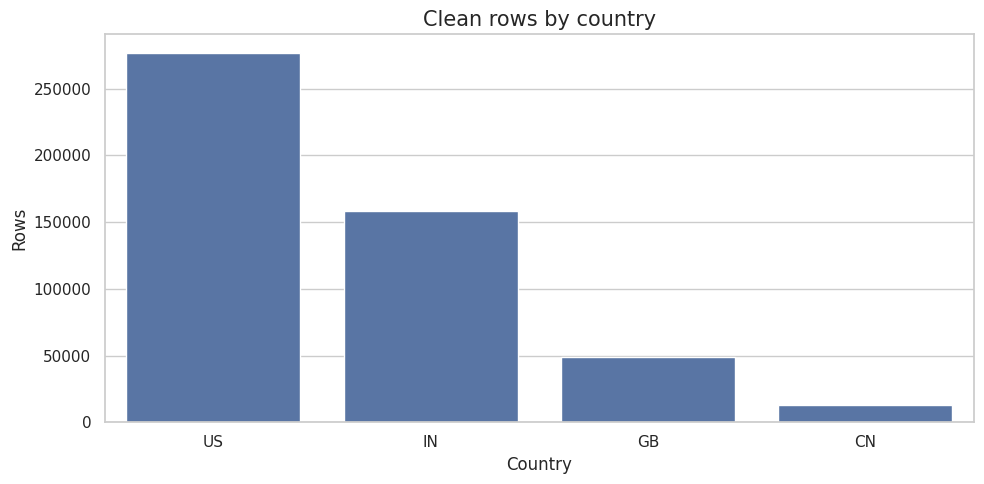

Figure saved to /kaggle/working/openaq_project_outputs/figures/06_Clean_rows_by_country.png


In [156]:

country_summary_df = (
    clean_air_quality_df.groupby("country")
    .agg(
        row_count=("value", "size"),
        city_count=("city", "nunique"),
        station_count=("station_id", "nunique"),
        pollutant_count=("pollutant", "nunique"),
        mean_value=("value", "mean"),
        median_value=("value", "median"),
    )
    .sort_values("row_count", ascending=False)
    .reset_index()
)
display(country_summary_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=country_summary_df, x="country", y="row_count")
plt.title("Clean rows by country")
plt.xlabel("Country")
plt.ylabel("Rows")
plt.tight_layout()
show_and_save_figure()

,pollutant,unit,row_count,country_count,station_count,mean_value,median_value,p95_value,max_value
0,pm25,µg/m³,122500,4,4282,23.501517,8.000,98.424,10000.000
1,o3,ppm,99687,3,1602,0.037668,0.038,0.058,0.098
2,pm10,µg/m³,71741,4,3229,81.970870,30.000,333.500,22028.490
3,no2,µg/m³,47649,4,2838,26.146270,17.060,78.828,3378.100
4,o3,µg/m³,35779,4,2646,48.067208,37.400,131.637,6918.000
5,so2,µg/m³,30704,3,2570,20.176871,8.460,49.000,7770.480
6,co,µg/m³,27515,3,2550,921.709566,700.000,2430.000,80000.000
7,no2,ppm,24166,1,421,0.007004,0.004,0.025,0.076
8,so2,ppm,20297,2,372,0.000608,0.000,0.002,0.178
9,co,ppm,15359,1,277,0.242168,0.200,0.520,14.500


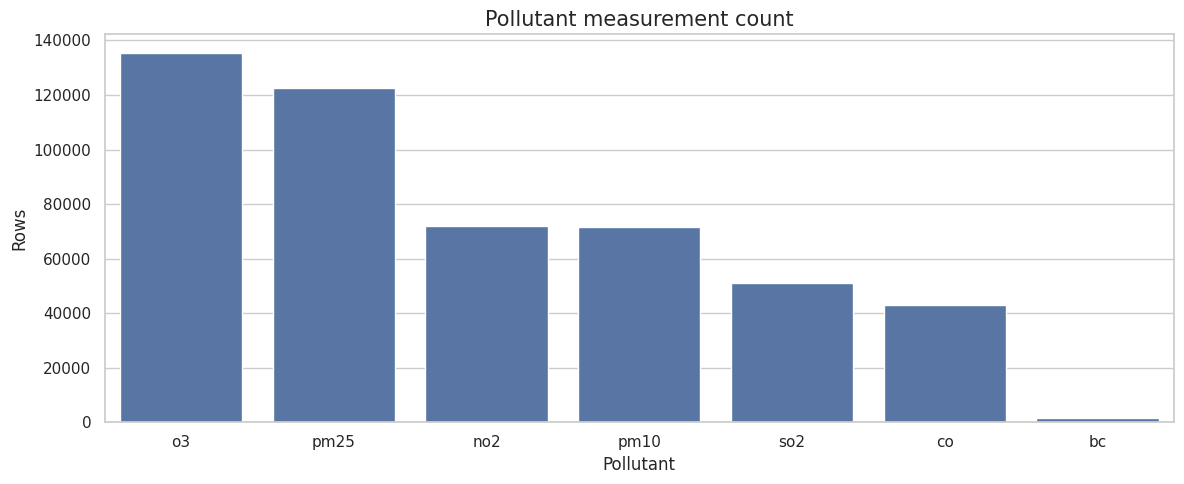

Figure saved to /kaggle/working/openaq_project_outputs/figures/07_Pollutant_measurement_count.png


In [157]:

pollutant_summary_df = (
    clean_air_quality_df.groupby(["pollutant", "unit"])
    .agg(
        row_count=("value", "size"),
        country_count=("country", "nunique"),
        station_count=("station_id", "nunique"),
        mean_value=("value", "mean"),
        median_value=("value", "median"),
        p95_value=("value", lambda series: np.percentile(series, 95)),
        max_value=("value", "max"),
    )
    .sort_values("row_count", ascending=False)
    .reset_index()
)
display(pollutant_summary_df)

plt.figure(figsize=(12, 5))
sns.countplot(data=clean_air_quality_df, x="pollutant", order=clean_air_quality_df["pollutant"].value_counts().index)
plt.title("Pollutant measurement count")
plt.xlabel("Pollutant")
plt.ylabel("Rows")
plt.tight_layout()
show_and_save_figure()

pollutant,bc,co,no2,o3,pm10,pm25,so2
country,,,,,,,
CN,0,2058,2058,2058,2058,2326,2058
GB,0,112,18521,7769,11330,8837,2615
IN,0,25345,27069,25954,26506,27364,26032
US,1489,15359,24167,99685,31847,83973,20296


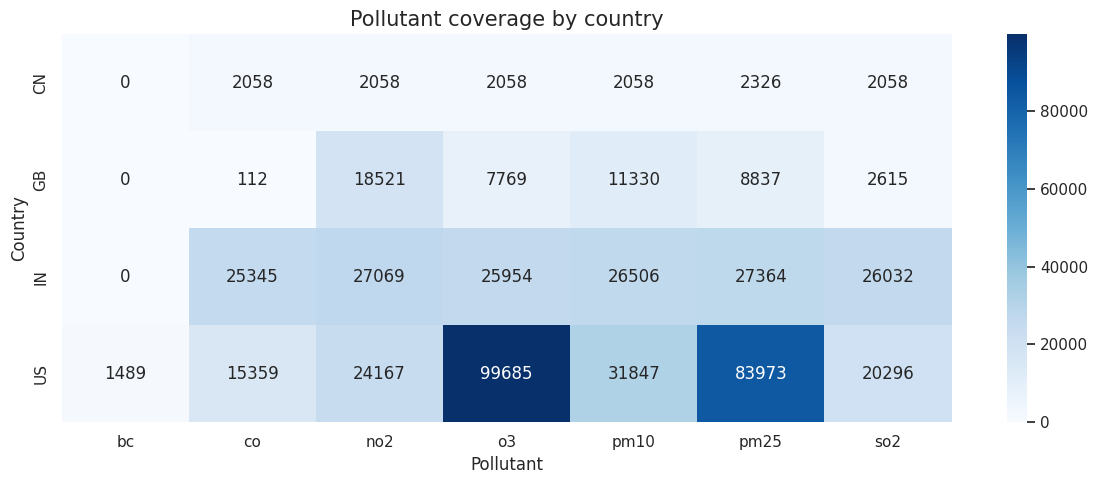

Figure saved to /kaggle/working/openaq_project_outputs/figures/08_Pollutant_coverage_by_country.png


In [158]:

pollutant_country_table = pd.crosstab(clean_air_quality_df["country"], clean_air_quality_df["pollutant"])
display(pollutant_country_table)

plt.figure(figsize=(12, 5))
sns.heatmap(pollutant_country_table, annot=True, fmt="d", cmap="Blues")
plt.title("Pollutant coverage by country")
plt.xlabel("Pollutant")
plt.ylabel("Country")
plt.tight_layout()
show_and_save_figure()

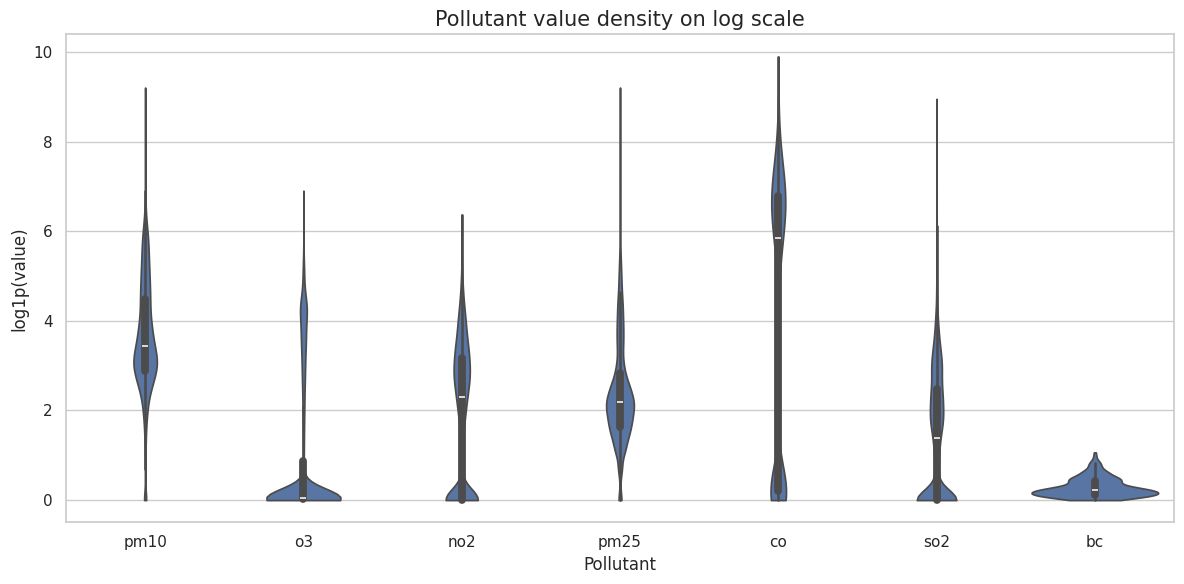

Figure saved to /kaggle/working/openaq_project_outputs/figures/10_Pollutant_value_density_on_log_scale.png


In [159]:

value_plot_df = clean_air_quality_df.copy()
value_plot_df["log_value"] = np.log1p(value_plot_df["value"])

plt.figure(figsize=(12, 6))
sns.boxplot(data=value_plot_df, x="pollutant", y="log_value")
plt.title("Pollutant value distribution on log scale")
plt.xlabel("Pollutant")
plt.ylabel("log1p(value)")
plt.tight_layout()
show_and_save_figure()
plt.figure(figsize=(12, 6))
sns.violinplot(data=value_plot_df.sample(min(len(value_plot_df), 80_000), random_state=config.random_seed), x="pollutant", y="log_value", cut=0)
plt.title("Pollutant value density on log scale")
plt.xlabel("Pollutant")
plt.ylabel("log1p(value)")
plt.tight_layout()
show_and_save_figure()

,year_month,row_count,station_count
63,2020-09,36,16
64,2020-10,21,15
65,2020-11,30,16
66,2020-12,1023,179
67,2021-01,38,21
68,2021-02,13,3
69,2021-03,18,10
70,2021-04,13,4
71,2021-05,17,8
72,2021-06,18,10


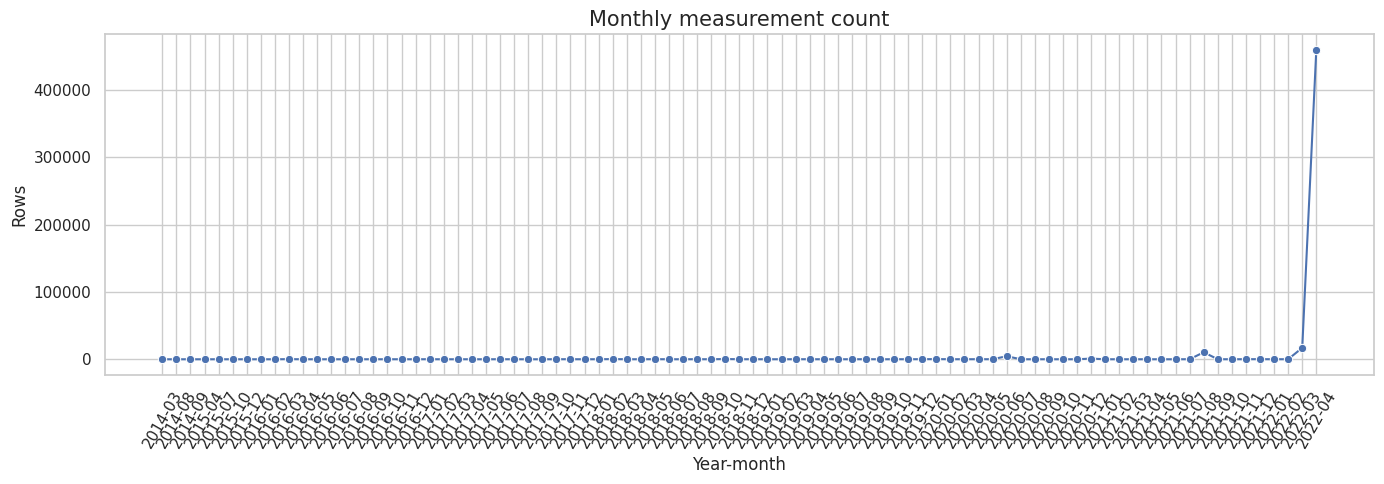

Figure saved to /kaggle/working/openaq_project_outputs/figures/11_Monthly_measurement_count.png


In [160]:

time_df = clean_air_quality_df.copy()
time_df["year_month"] = time_df["timestamp"].dt.to_period("M").astype(str)
time_df["year"] = time_df["timestamp"].dt.year
ntime_summary_df = (
    time_df.groupby("year_month")
    .agg(row_count=("value", "size"), station_count=("station_id", "nunique"))
    .reset_index()
    .sort_values("year_month")
)
display(ntime_summary_df.tail(20))

plt.figure(figsize=(14, 5))
sns.lineplot(data=ntime_summary_df, x="year_month", y="row_count", marker="o")
plt.title("Monthly measurement count")
plt.xlabel("Year-month")
plt.ylabel("Rows")
plt.xticks(rotation=60)
plt.tight_layout()
show_and_save_figure()

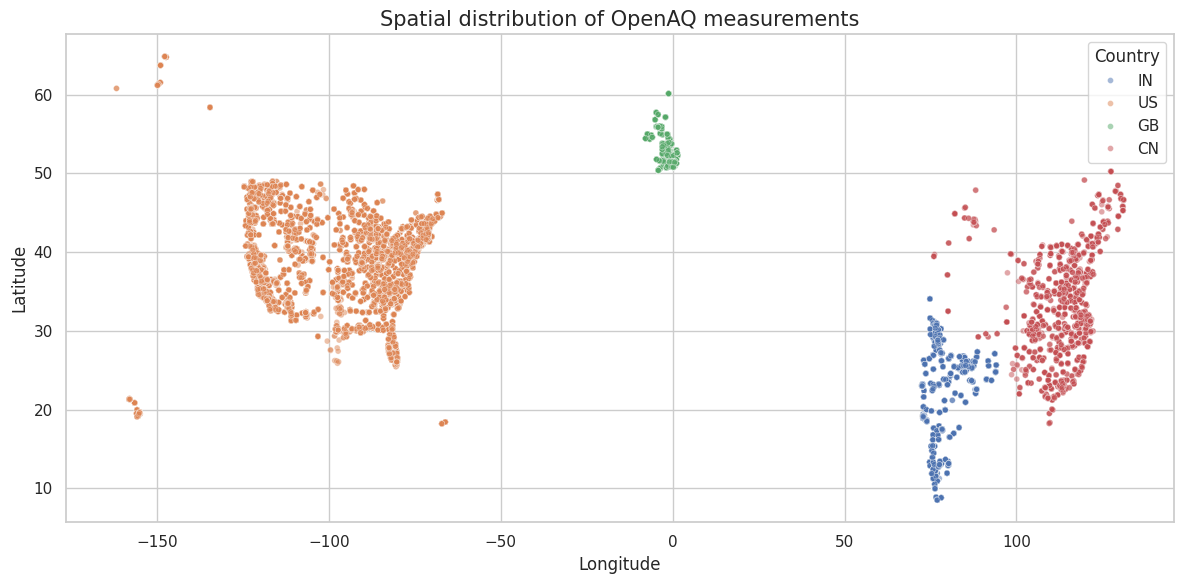

Figure saved to /kaggle/working/openaq_project_outputs/figures/12_Spatial_distribution_of_OpenAQ_measurements.png


In [161]:

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=clean_air_quality_df.sample(min(len(clean_air_quality_df), 100_000), random_state=config.random_seed),
    x="longitude",
    y="latitude",
    hue="country",
    alpha=0.5,
    s=18,
)
plt.title("Spatial distribution of OpenAQ measurements")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Country")
plt.tight_layout()
show_and_save_figure()

,country,city,row_count
615,IN,Delhi,17503
717,IN,Mumbai,8526
1404,US,Phoenix-Mesa-Scottsdale,7485
1441,US,Riverside-San Bernardino-Ontario,5732
1250,US,Los Angeles-Long Beach-Santa Ana,5559
1348,US,New York-Northern New Jersey-Long Island,4673
578,IN,Bengaluru,4067
604,IN,Chennai,4046
1501,US,San Francisco-Oakland-Fremont,4031
479,GB,London,3927


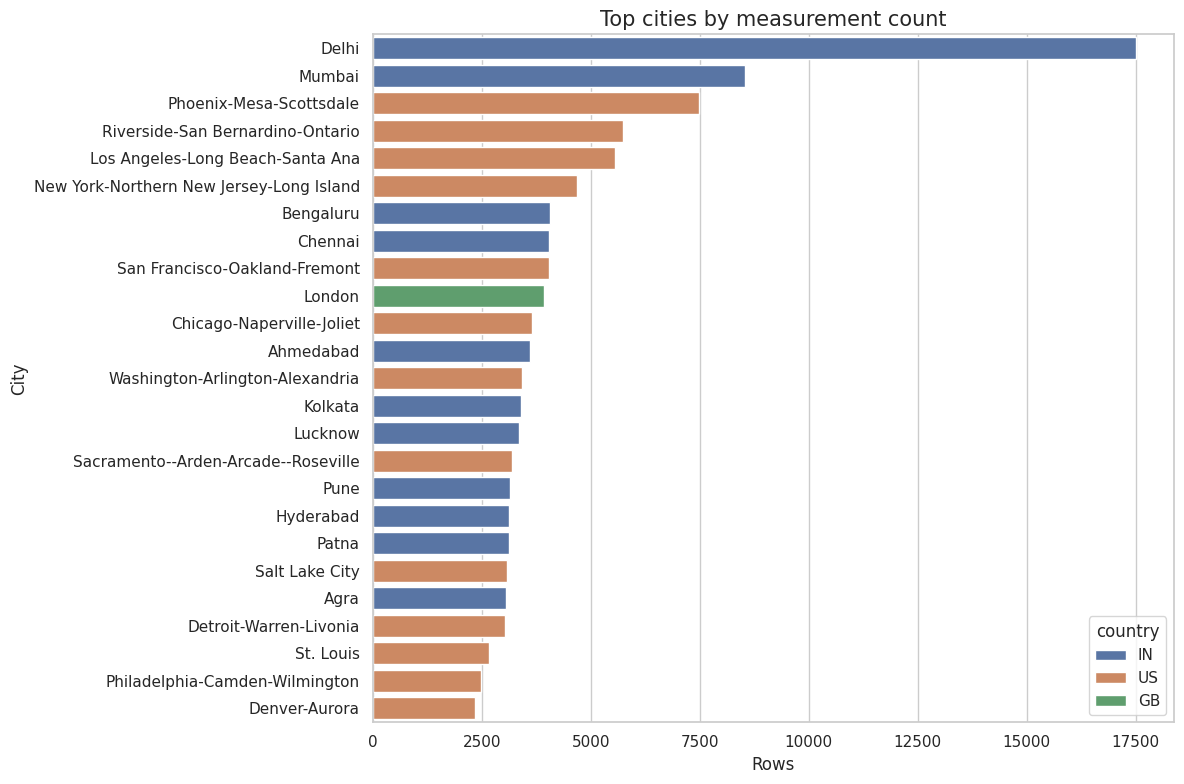

Figure saved to /kaggle/working/openaq_project_outputs/figures/13_Top_cities_by_measurement_count.png


In [162]:

city_pollutant_summary_df = (
    clean_air_quality_df.groupby(["country", "city", "pollutant"])
    .agg(row_count=("value", "size"), mean_value=("value", "mean"), median_value=("value", "median"))
    .reset_index()
)

top_city_counts_df = (
    clean_air_quality_df.groupby(["country", "city"])
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
    .head(25)
)
display(top_city_counts_df)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_city_counts_df, x="row_count", y="city", hue="country", dodge=False)
plt.title("Top cities by measurement count")
plt.xlabel("Rows")
plt.ylabel("City")
plt.tight_layout()
show_and_save_figure()

## 7. PM2.5 target analysis

The project uses PM2.5 as the main modelling target because it is common in air-quality forecasting, strongly relevant to environmental health, and normally measured in a consistent mass-concentration unit.

In [163]:

def standardise_unit_text(unit_value: object) -> str:
    """Standardise common air-quality unit labels."""
    text_value = str(unit_value).lower().strip()
    text_value = text_value.replace("μ", "µ")
    text_value = text_value.replace("ug/m3", "µg/m³")
    text_value = text_value.replace("ug/m³", "µg/m³")
    return text_value

pm25_df = clean_air_quality_df[clean_air_quality_df["pollutant"].eq(config.target_pollutant)].copy()
pm25_df["unit_standardised"] = pm25_df["unit"].apply(standardise_unit_text)

before_pm25_rows = len(pm25_df)
pm25_df = pm25_df[pm25_df["value"].between(0, 500)]
pm25_df = pm25_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)
after_pm25_rows = len(pm25_df)

print(f"PM2.5 rows before target cleaning: {before_pm25_rows:,}")
print(f"PM2.5 rows after target cleaning: {after_pm25_rows:,}")
print(f"Rows removed from PM2.5 due to invalid/extreme values: {before_pm25_rows - after_pm25_rows:,}")

display(pm25_df.head())

PM2.5 rows before target cleaning: 122,500
PM2.5 rows after target cleaning: 122,321
Rows removed from PM2.5 due to invalid/extreme values: 179


,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,coordinate_status,station_id,unit_standardised
0,Anqing An Qing Da Xue,Anqing,CN,pm25,75.0,2018-10-13 21:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,valid,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989,µg/m³
1,Anqing An Qing Da Xue,Anqing,CN,pm25,36.0,2019-12-27 09:00:00+00:00,µg/m³,Anqing,30.6145,116.9894,1.0,repaired_shift,CN_Anqing_Anqing An Qing Da Xue_30.614_116.989,µg/m³
2,Anqing Huan Ke Yuan,Anqing,CN,pm25,65.0,2018-10-13 21:00:00+00:00,µg/m³,Anqing,30.5103,117.0549,1.0,valid,CN_Anqing_Anqing Huan Ke Yuan_30.51_117.055,µg/m³
3,Anqing Lian Fu Hua Yuan,Anqing,CN,pm25,6.0,2018-08-16 04:00:00+00:00,µg/m³,Anqing,30.5489,117.0486,1.0,repaired_shift,CN_Anqing_Anqing Lian Fu Hua Yuan_30.549_117.049,µg/m³
4,Anqing Lian Fu Hua Yuan,Anqing,CN,pm25,6.0,2018-08-16 04:00:00+00:00,µg/m³,Anqing,30.5489,117.0486,1.0,valid,CN_Anqing_Anqing Lian Fu Hua Yuan_30.549_117.049,µg/m³


,country,row_count,city_count,station_count,mean_pm25,median_pm25,p75_pm25,p95_pm25,max_pm25
0,IN,27193,259,526,70.096080,50.0,89.0,200.5,497.0
1,CN,2322,394,2041,23.132644,19.0,29.0,56.0,279.0
2,GB,8837,88,138,9.778137,9.0,12.0,18.0,62.0
3,US,83969,615,1574,6.984986,6.0,9.0,16.0,430.0


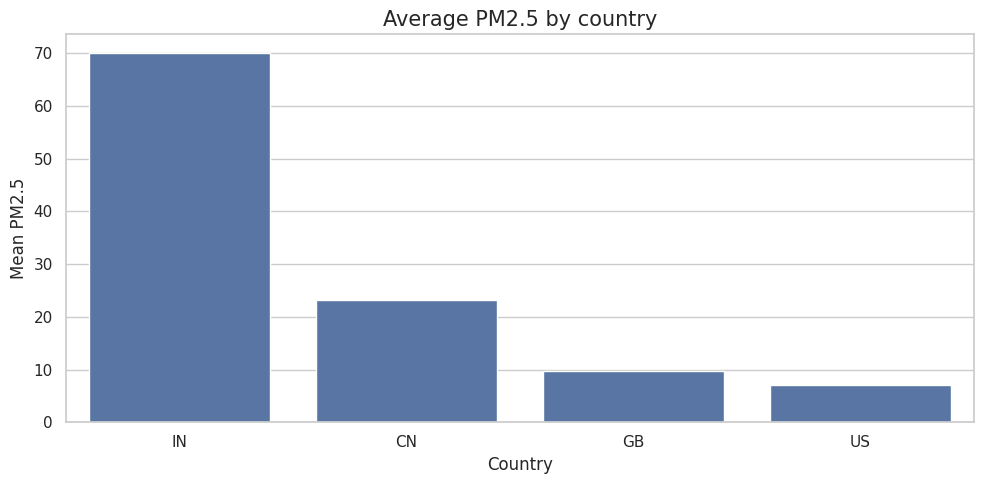

Figure saved to /kaggle/working/openaq_project_outputs/figures/14_Average_PM2_5_by_country.png


In [ ]:

pm25_country_summary_df = (
    pm25_df.groupby("country")
    .agg(
        row_count=("value", "size"),
        city_count=("city", "nunique"),
        station_count=("station_id", "nunique"),
        mean_pm25=("value", "mean"),
        median_pm25=("value", "median"),
        p75_pm25=("value", lambda series: np.percentile(series, 75)),
        p95_pm25=("value", lambda series: np.percentile(series, 95)),
        max_pm25=("value", "max"),
    )
    .sort_values("mean_pm25", ascending=False)
    .reset_index()
)
display(pm25_country_summary_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=pm25_country_summary_df, x="country", y="mean_pm25")
plt.title("Average PM2.5 by country")
plt.xlabel("Country")
plt.ylabel("Mean PM2.5")
plt.tight_layout()
show_and_save_figure()

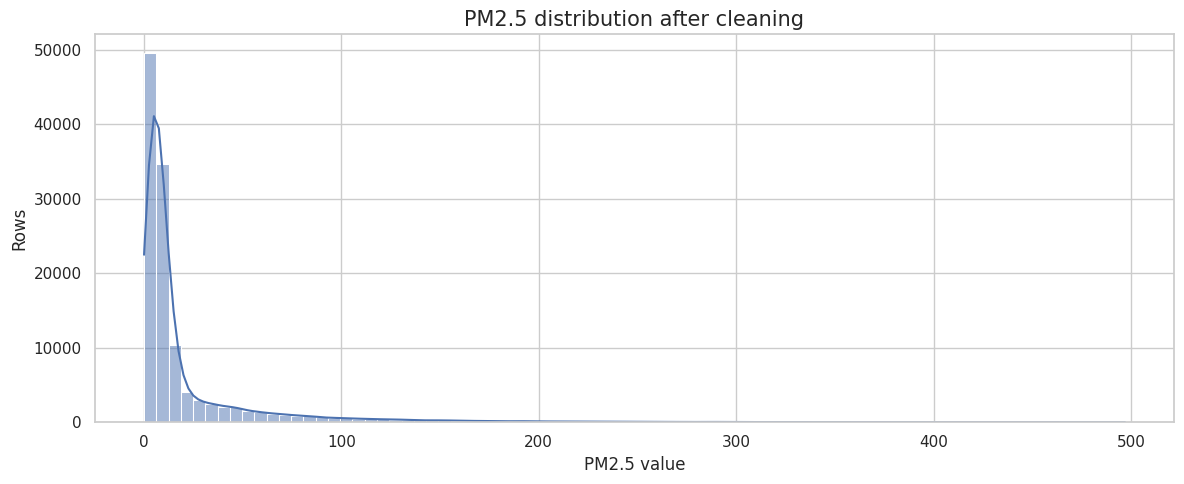

Figure saved to /kaggle/working/openaq_project_outputs/figures/15_PM2_5_distribution_after_cleaning.png


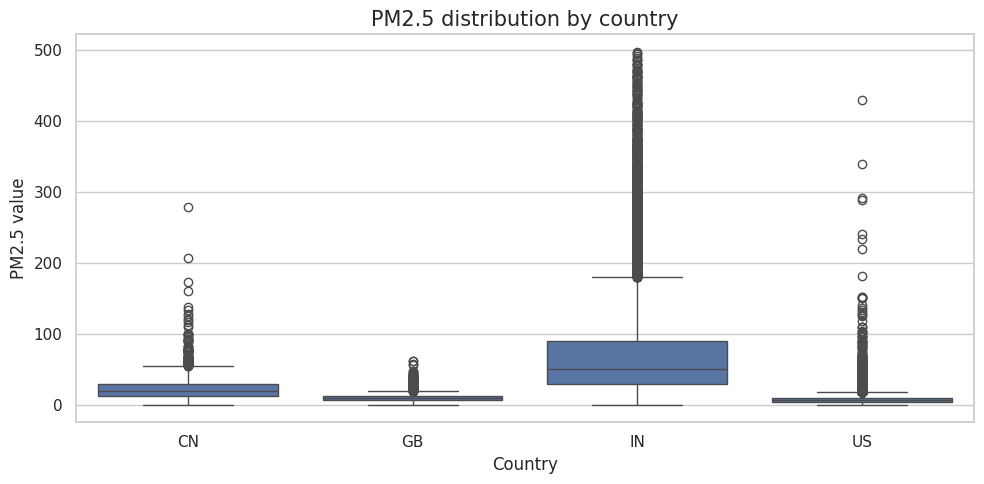

Figure saved to /kaggle/working/openaq_project_outputs/figures/16_PM2_5_distribution_by_country.png


In [ ]:

plt.figure(figsize=(12, 5))
sns.histplot(data=pm25_df, x="value", bins=80, kde=True)
plt.title("PM2.5 distribution after cleaning")
plt.xlabel("PM2.5 value")
plt.ylabel("Rows")
plt.tight_layout()
show_and_save_figure()
plt.figure(figsize=(10, 5))
sns.boxplot(data=pm25_df, x="country", y="value")
plt.title("PM2.5 distribution by country")
plt.xlabel("Country")
plt.ylabel("PM2.5 value")
plt.tight_layout()
show_and_save_figure()

,country,city,row_count,mean_pm25,median_pm25
0,IN,Hapur,91,186.296703,184.000
1,IN,Muzaffarnagar,83,174.036145,170.000
2,IN,Baghpat,71,167.239437,163.000
3,IN,Bahadurgarh,83,153.561566,150.800
4,IN,Meerut,264,146.863636,132.000
5,IN,Delhi,3065,145.027847,125.200
6,IN,Ghaziabad,319,143.667712,113.000
7,IN,Mandi Gobindgarh,81,141.350247,116.240
8,IN,Singrauli,93,139.053763,149.000
9,IN,Rohtak,97,129.588969,121.780


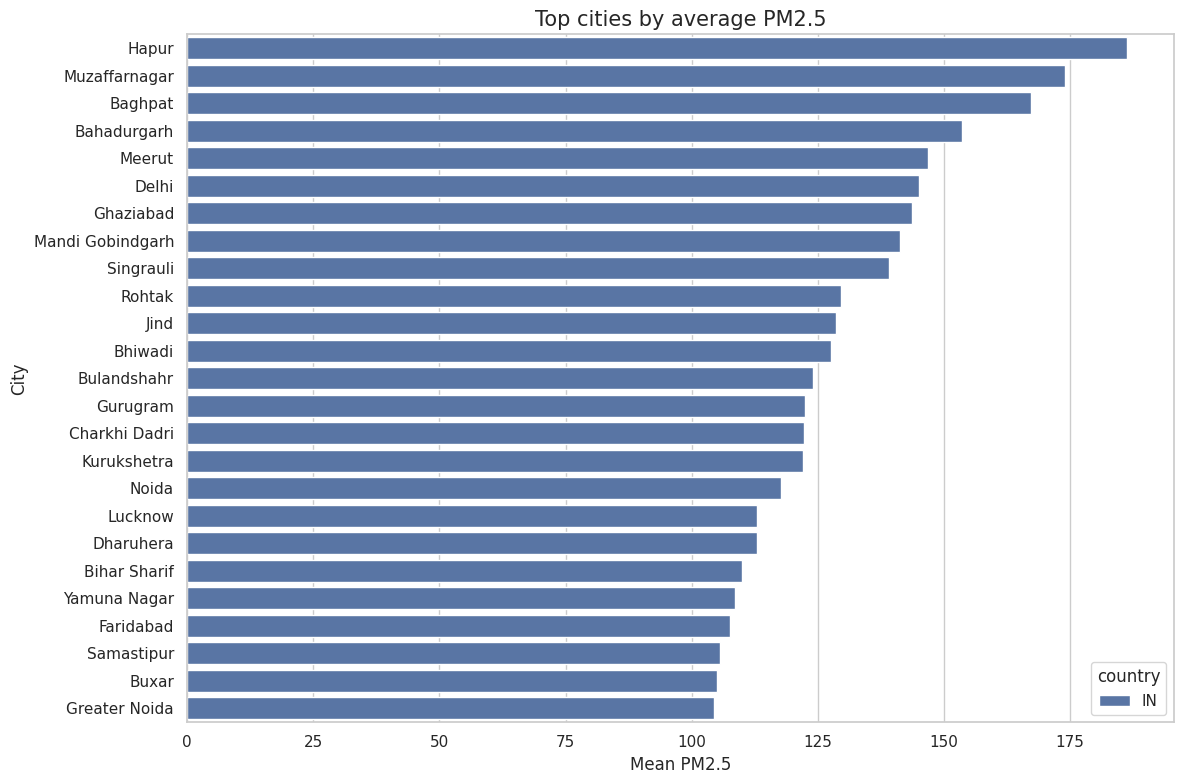

Figure saved to /kaggle/working/openaq_project_outputs/figures/17_Top_cities_by_average_PM2_5.png


In [ ]:

pm25_city_summary_df = (
    pm25_df.groupby(["country", "city"])
    .agg(row_count=("value", "size"), mean_pm25=("value", "mean"), median_pm25=("value", "median"))
    .query("row_count >= 50")
    .sort_values("mean_pm25", ascending=False)
    .head(25)
    .reset_index()
)
display(pm25_city_summary_df)

plt.figure(figsize=(12, 8))
sns.barplot(data=pm25_city_summary_df, x="mean_pm25", y="city", hue="country", dodge=False)
plt.title("Top cities by average PM2.5")
plt.xlabel("Mean PM2.5")
plt.ylabel("City")
plt.tight_layout()
show_and_save_figure()

,year_month,country,mean_pm25,row_count
136,2021-11,GB,4.000000,1
137,2021-11,IN,70.750000,2
138,2021-11,US,7.628571,28
139,2021-12,GB,2.000000,1
140,2021-12,IN,141.497500,4
141,2021-12,US,5.618182,22
142,2022-01,GB,9.000000,1
143,2022-01,IN,155.500000,2
144,2022-01,US,12.558333,12
145,2022-02,GB,2.600000,1


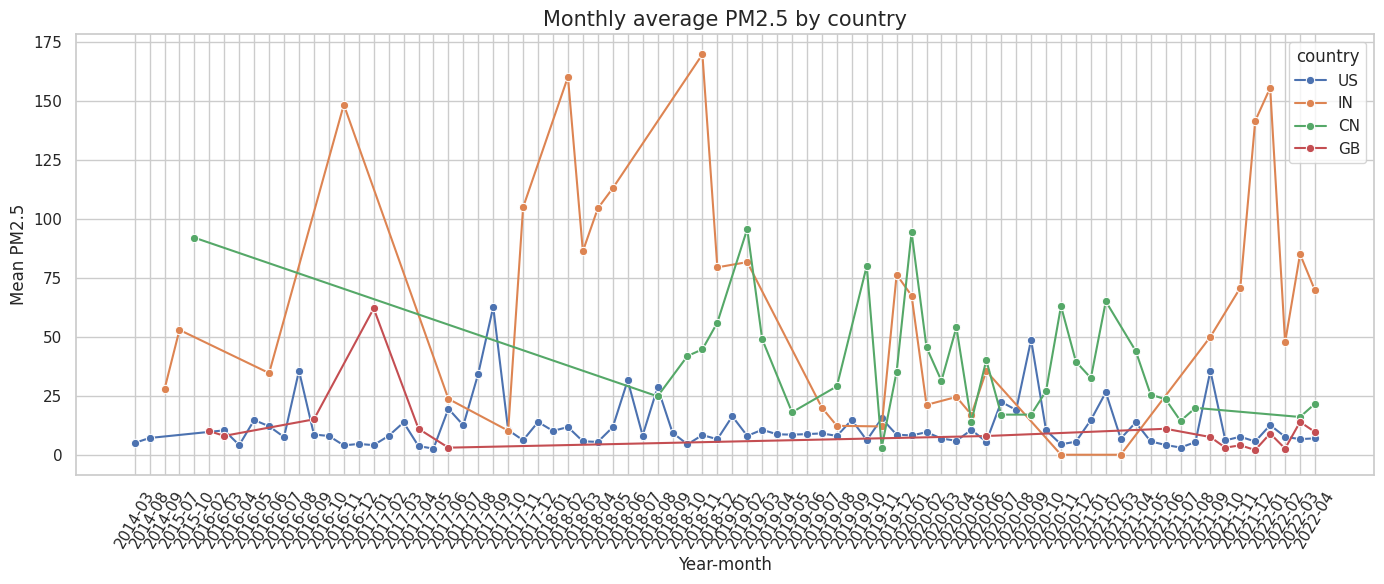

Figure saved to /kaggle/working/openaq_project_outputs/figures/18_Monthly_average_PM2_5_by_country.png


In [ ]:

pm25_time_df = pm25_df.copy()
pm25_time_df["year_month"] = pm25_time_df["timestamp"].dt.to_period("M").astype(str)
pm25_time_df["hour"] = pm25_time_df["timestamp"].dt.hour
pm25_time_df["weekday"] = pm25_time_df["timestamp"].dt.day_name()

monthly_pm25_df = (
    pm25_time_df.groupby(["year_month", "country"])
    .agg(mean_pm25=("value", "mean"), row_count=("value", "size"))
    .reset_index()
)
display(monthly_pm25_df.tail(20))

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_pm25_df, x="year_month", y="mean_pm25", hue="country", marker="o")
plt.title("Monthly average PM2.5 by country")
plt.xlabel("Year-month")
plt.ylabel("Mean PM2.5")
plt.xticks(rotation=60)
plt.tight_layout()
show_and_save_figure()

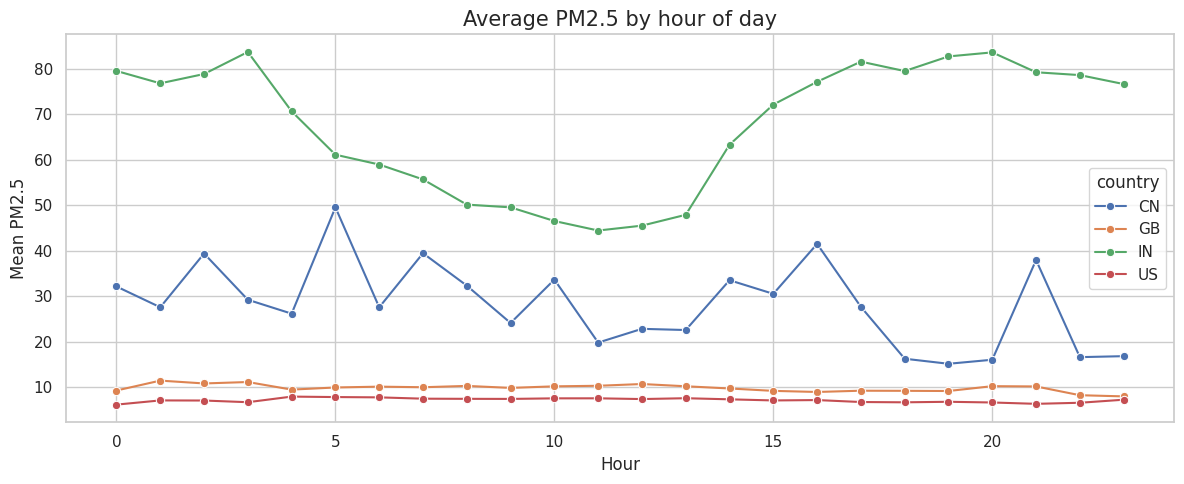

Figure saved to /kaggle/working/openaq_project_outputs/figures/19_Average_PM2_5_by_hour_of_day.png


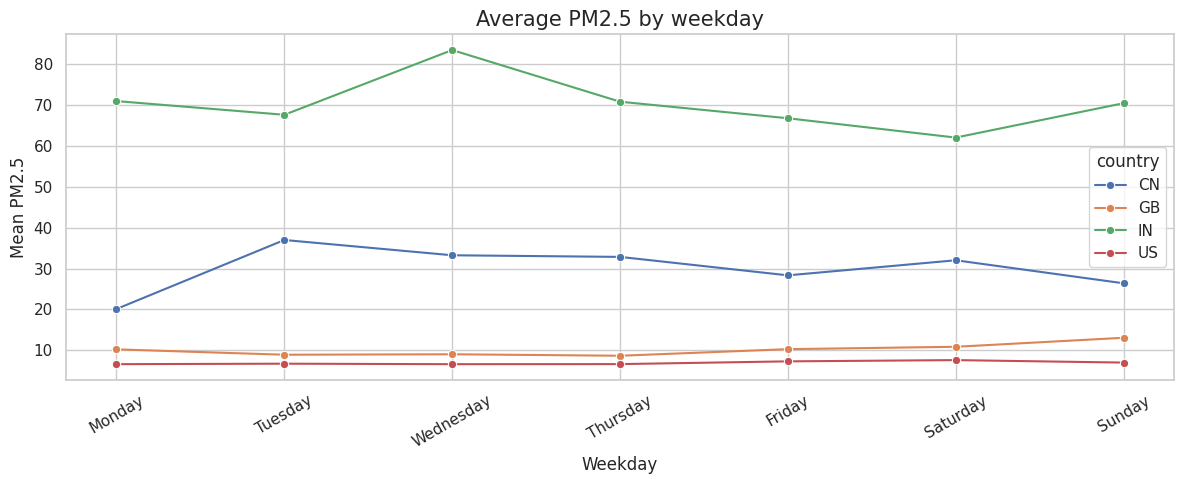

Figure saved to /kaggle/working/openaq_project_outputs/figures/20_Average_PM2_5_by_weekday.png


In [ ]:

hourly_pm25_df = (
    pm25_time_df.groupby(["hour", "country"])
    .agg(mean_pm25=("value", "mean"), row_count=("value", "size"))
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_pm25_df, x="hour", y="mean_pm25", hue="country", marker="o")
plt.title("Average PM2.5 by hour of day")
plt.xlabel("Hour")
plt.ylabel("Mean PM2.5")
plt.tight_layout()
show_and_save_figure()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_pm25_df = (
    pm25_time_df.groupby(["weekday", "country"])
    .agg(mean_pm25=("value", "mean"), row_count=("value", "size"))
    .reset_index()
)
weekday_pm25_df["weekday"] = pd.Categorical(weekday_pm25_df["weekday"], categories=weekday_order, ordered=True)
weekday_pm25_df = weekday_pm25_df.sort_values("weekday")

plt.figure(figsize=(12, 5))
sns.lineplot(data=weekday_pm25_df, x="weekday", y="mean_pm25", hue="country", marker="o")
plt.title("Average PM2.5 by weekday")
plt.xlabel("Weekday")
plt.ylabel("Mean PM2.5")
plt.xticks(rotation=30)
plt.tight_layout()
show_and_save_figure()

,station_id,country,city,location,latitude,longitude,mean_pm25,median_pm25,row_count
249,"IN_Ghaziabad_Loni, Ghaziabad - UPPCB_28.757_77...",IN,Ghaziabad,"Loni, Ghaziabad - UPPCB",28.757294,77.278792,255.698630,272.00,73
198,"IN_Delhi_DTU, Delhi - CPCB_28.75_77.111",IN,Delhi,"DTU, Delhi - CPCB",28.750050,77.111261,214.316667,182.40,36
194,"IN_Delhi_Bawana, Delhi - DPCC_28.776_77.051",IN,Delhi,"Bawana, Delhi - DPCC",28.776200,77.051074,213.977273,191.00,88
213,"IN_Delhi_Narela, Delhi - DPCC_28.823_77.102",IN,Delhi,"Narela, Delhi - DPCC",28.822836,77.101981,207.777778,199.50,90
210,"IN_Delhi_Mundka, Delhi - DPCC_28.685_77.077",IN,Delhi,"Mundka, Delhi - DPCC",28.684678,77.076574,207.164835,193.00,91
326,IN_Lucknow_Talkatora District Industries Cente...,IN,Lucknow,"Talkatora District Industries Center, Lucknow ...",26.833997,80.891736,206.238043,194.25,92
204,"IN_Delhi_Jahangirpuri, Delhi - DPCC_28.733_77.171",IN,Delhi,"Jahangirpuri, Delhi - DPCC",28.732820,77.170633,202.842697,179.00,89
221,"IN_Delhi_Rohini, Delhi - DPCC_28.733_77.12",IN,Delhi,"Rohini, Delhi - DPCC",28.732528,77.119920,199.090909,173.00,77
190,"IN_Delhi_Alipur, Delhi - DPCC_28.815_77.153",IN,Delhi,"Alipur, Delhi - DPCC",28.815329,77.153010,192.712500,182.50,80
218,"IN_Delhi_Punjabi Bagh, Delhi - DPCC_28.674_77.131",IN,Delhi,"Punjabi Bagh, Delhi - DPCC",28.674045,77.131023,189.090909,163.50,88


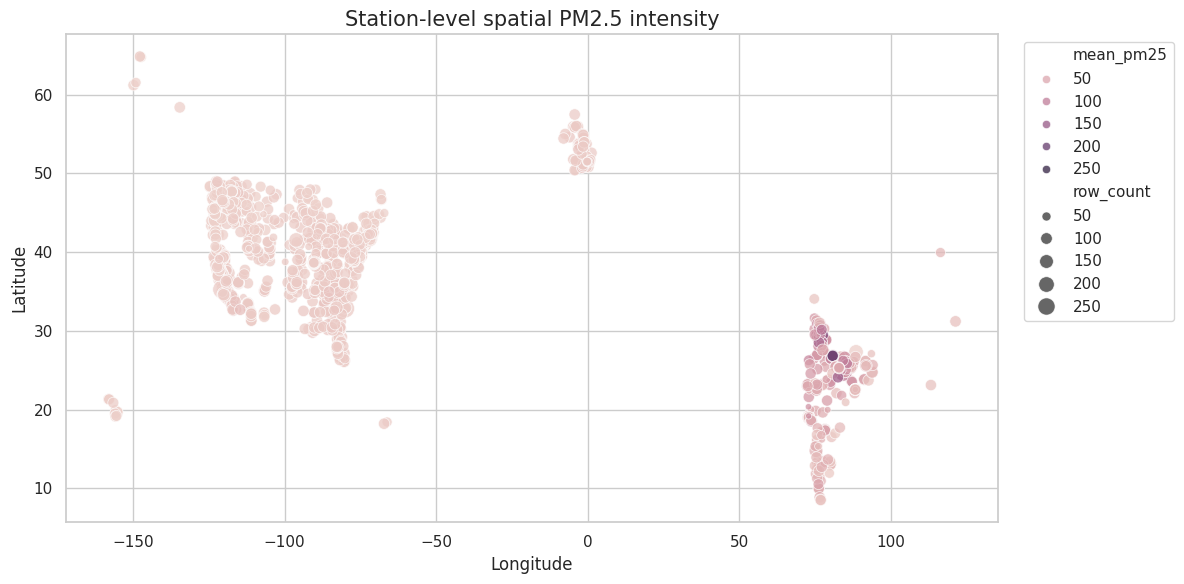

Figure saved to /kaggle/working/openaq_project_outputs/figures/21_Station-level_spatial_PM2_5_intensity.png


In [ ]:

station_pm25_geo_df = (
    pm25_df.groupby(["station_id", "country", "city", "location"])
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        mean_pm25=("value", "mean"),
        median_pm25=("value", "median"),
        row_count=("value", "size"),
    )
    .query("row_count >= 10")
    .reset_index()
)
display(station_pm25_geo_df.sort_values("mean_pm25", ascending=False).head(20))

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=station_pm25_geo_df,
    x="longitude",
    y="latitude",
    size="row_count",
    hue="mean_pm25",
    alpha=0.75,
    sizes=(20, 180),
)
plt.title("Station-level spatial PM2.5 intensity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_and_save_figure()

In [ ]:

if FOLIUM_AVAILABLE and len(station_pm25_geo_df) > 0:
    map_sample_df = station_pm25_geo_df.sort_values("row_count", ascending=False).head(500)
    map_center = [map_sample_df["latitude"].mean(), map_sample_df["longitude"].mean()]
    air_quality_map = folium.Map(location=map_center, zoom_start=2, tiles="CartoDB positron")
    marker_cluster = MarkerCluster().add_to(air_quality_map)

    for _, row in map_sample_df.iterrows():
        popup_text = (
            f"Country: {row['country']}<br>"
            f"City: {row['city']}<br>"
            f"Location: {row['location']}<br>"
            f"Mean PM2.5: {row['mean_pm25']:.2f}<br>"
            f"Rows: {int(row['row_count'])}"
        )
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=5,
            popup=popup_text,
            fill=True,
            fill_opacity=0.7,
        ).add_to(marker_cluster)

    map_path = Path(config.output_dir) / "pm25_station_map.html"
    air_quality_map.save(map_path)
    print(f"Interactive map saved to {map_path}")
    display(air_quality_map)
else:
    print("Folium map skipped because folium is unavailable or no station data exists.")

Interactive map saved to /kaggle/working/openaq_project_outputs/pm25_station_map.html


## 8. Feature engineering for forecasting

The model predicts the next available PM2.5 reading for each station. Lag and rolling features preserve the time-series structure, and the split is chronological to avoid leakage.

In [ ]:
def build_pm25_forecasting_dataset(pm25_source_df: pd.DataFrame, project_config: ProjectConfig) -> pd.DataFrame:
    """Create a next-reading PM2.5 forecasting dataset without future-derived predictors."""
    modelling_df = pm25_source_df.copy()

    station_counts = modelling_df["station_id"].value_counts()
    eligible_stations = station_counts[
        station_counts >= project_config.minimum_station_records
    ].index
    modelling_df = modelling_df[
        modelling_df["station_id"].isin(eligible_stations)
    ].copy()

    modelling_df = modelling_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

    # Calendar and cyclical features available at prediction time.
    modelling_df["hour"] = modelling_df["timestamp"].dt.hour
    modelling_df["day"] = modelling_df["timestamp"].dt.day
    modelling_df["month"] = modelling_df["timestamp"].dt.month
    modelling_df["weekday"] = modelling_df["timestamp"].dt.dayofweek
    modelling_df["day_of_year"] = modelling_df["timestamp"].dt.dayofyear
    modelling_df["is_weekend"] = modelling_df["weekday"].isin([5, 6]).astype(int)

    modelling_df["hour_sin"] = np.sin(2 * np.pi * modelling_df["hour"] / 24)
    modelling_df["hour_cos"] = np.cos(2 * np.pi * modelling_df["hour"] / 24)
    modelling_df["month_sin"] = np.sin(2 * np.pi * modelling_df["month"] / 12)
    modelling_df["month_cos"] = np.cos(2 * np.pi * modelling_df["month"] / 12)

    # Historical station-level PM2.5 features. Every lag/rolling statistic uses only past values.
    group_object = modelling_df.groupby("station_id", group_keys=False)["value"]
    for lag_window in [1, 2, 3, 6, 12, 24]:
        modelling_df[f"pm25_lag_{lag_window}"] = group_object.shift(lag_window)

    shifted_values = group_object.shift(1)
    for rolling_window in [3, 6, 12, 24]:
        modelling_df[f"pm25_rolling_mean_{rolling_window}"] = (
            shifted_values.groupby(modelling_df["station_id"])
            .rolling(rolling_window, min_periods=2)
            .mean()
            .reset_index(level=0, drop=True)
        )
        modelling_df[f"pm25_rolling_std_{rolling_window}"] = (
            shifted_values.groupby(modelling_df["station_id"])
            .rolling(rolling_window, min_periods=2)
            .std()
            .reset_index(level=0, drop=True)
        )

    # Target = next available PM2.5 observation at the same station.
    modelling_df["target_pm25_next_reading"] = (
        modelling_df.groupby("station_id")["value"].shift(-1)
    )
    modelling_df["next_timestamp"] = (
        modelling_df.groupby("station_id")["timestamp"].shift(-1)
    )

    # IMPORTANT: this future-derived interval is retained only for audit/filtering.
    # It is deliberately excluded from all model feature lists below.
    modelling_df["forecast_gap_hours"] = (
        modelling_df["next_timestamp"] - modelling_df["timestamp"]
    ).dt.total_seconds() / 3600

    required_rows = [
        "target_pm25_next_reading",
        "next_timestamp",
        "forecast_gap_hours",
        "pm25_lag_1",
        "pm25_lag_2",
        "pm25_lag_3",
        "pm25_rolling_mean_3",
        "pm25_rolling_mean_6",
    ]
    modelling_df = modelling_df.dropna(subset=required_rows).copy()

    # Remove duplicate-time/non-forward targets and highly irregular long gaps.
    modelling_df = modelling_df[
        modelling_df["forecast_gap_hours"].gt(0)
        & modelling_df["forecast_gap_hours"].le(project_config.maximum_forecast_gap_hours)
    ].copy()

    # Use the most recent modelling window if a cap is required.
    modelling_df = modelling_df.sort_values(["timestamp", "station_id"]).reset_index(drop=True)
    if len(modelling_df) > project_config.modelling_sample_limit:
        modelling_df = modelling_df.tail(project_config.modelling_sample_limit).copy()

    modelling_df = modelling_df.reset_index(drop=True)
    modelling_df["model_row_id"] = np.arange(len(modelling_df), dtype=np.int64)
    return modelling_df


model_ready_df = build_pm25_forecasting_dataset(pm25_df, config)
model_dataset_path = Path(config.output_dir) / "pm25_model_ready_dataset.csv"
model_ready_df.to_csv(model_dataset_path, index=False)
print(f"Model-ready dataset shape: {model_ready_df.shape}")
print(f"Model-ready dataset saved to {model_dataset_path}")
print(
    "Observed forecast-gap range retained for audit: "
    f"{model_ready_df['forecast_gap_hours'].min():.3f} to "
    f"{model_ready_df['forecast_gap_hours'].max():.3f} hours"
)
display(model_ready_df.head())


Model-ready dataset shape: (90000, 42)
Model-ready dataset saved to /kaggle/working/openaq_project_outputs/pm25_model_ready_dataset.csv
Observed forecast-gap range retained for audit: 0.250 to 72.000 hours


,location,city,country,pollutant,value,timestamp,unit,source_name,latitude,longitude,averaged_over_in_hours,coordinate_status,station_id,unit_standardised,hour,day,month,weekday,day_of_year,is_weekend,hour_sin,hour_cos,month_sin,month_cos,pm25_lag_1,pm25_lag_2,pm25_lag_3,pm25_lag_6,pm25_lag_12,pm25_lag_24,pm25_rolling_mean_3,pm25_rolling_std_3,pm25_rolling_mean_6,pm25_rolling_std_6,pm25_rolling_mean_12,pm25_rolling_std_12,pm25_rolling_mean_24,pm25_rolling_std_24,target_pm25_next_reading,next_timestamp,forecast_gap_hours,model_row_id
0,Chesterfield,CHESTERFIELD,US,pm25,9.2,2022-04-18 03:00:00+00:00,µg/m³,AirNow,34.615299,-80.198898,1.0,repaired_shift,US_CHESTERFIELD_Chesterfield_34.615_-80.199,µg/m³,3,18,4,0,108,0,0.707107,0.707107,0.866025,-0.5,6.5,9.5,8.5,30.7,2.3,NaN,8.166667,1.527525,13.483333,9.947144,9.375000,8.096029,8.790000,6.512894,4.5,2022-04-19 03:00:00+00:00,24.0,0
1,Estacada Clackamas R,CLACKAMAS,US,pm25,3.7,2022-04-18 03:00:00+00:00,µg/m³,AirNow,45.291413,-122.332626,1.0,repaired_shift,US_CLACKAMAS_Estacada Clackamas R_45.291_-122.333,µg/m³,3,18,4,0,108,0,0.707107,0.707107,0.866025,-0.5,3.7,3.4,3.4,3.7,6.9,NaN,3.500000,0.173205,4.533333,2.388026,4.641667,2.226068,4.873684,2.688833,2.6,2022-04-19 03:00:00+00:00,24.0,1
2,Port Angeles-E 5th S,CLALLAM,US,pm25,6.9,2022-04-18 03:00:00+00:00,µg/m³,AirNow,48.115000,-123.436434,1.0,repaired_shift,US_CLALLAM_Port Angeles-E 5th S_48.115_-123.436,µg/m³,3,18,4,0,108,0,0.707107,0.707107,0.866025,-0.5,5.0,4.6,6.4,4.4,5.7,NaN,5.333333,0.945163,5.066667,0.987252,5.250000,1.842183,5.230000,2.666971,2.7,2022-04-19 03:00:00+00:00,24.0,2
3,Jeffersonville - Bat,CLARK,US,pm25,4.0,2022-04-18 03:00:00+00:00,µg/m³,AirNow,38.288191,-85.741337,1.0,repaired_shift,US_CLARK_Jeffersonville - Bat_38.288_-85.741,µg/m³,3,18,4,0,108,0,0.707107,0.707107,0.866025,-0.5,3.7,6.4,7.0,6.3,19.0,NaN,5.700000,1.757840,6.100000,2.462519,8.575000,5.819891,9.150000,5.065622,5.6,2022-04-19 03:00:00+00:00,24.0,3
4,RT,CLARK,US,pm25,7.7,2022-04-18 03:00:00+00:00,µg/m³,AirNow,36.139707,-115.175654,1.0,repaired_shift,US_CLARK_RT_36.14_-115.176,µg/m³,3,18,4,0,108,0,0.707107,0.707107,0.866025,-0.5,12.5,5.9,6.8,39.6,2.8,NaN,8.400000,3.579106,12.833333,13.414271,10.566667,9.615644,8.409524,7.657343,7.8,2022-04-19 03:00:00+00:00,24.0,4


,metric,value
0,model_ready_rows,90000
1,stations,1322
2,cities,733
3,countries,4
4,start_timestamp,2022-04-18 03:00:00+00:00
5,end_timestamp,2022-04-30 13:00:00+00:00
6,target_mean,21.113489
7,target_median,8.0
8,target_min,0.0
9,target_max,497.0


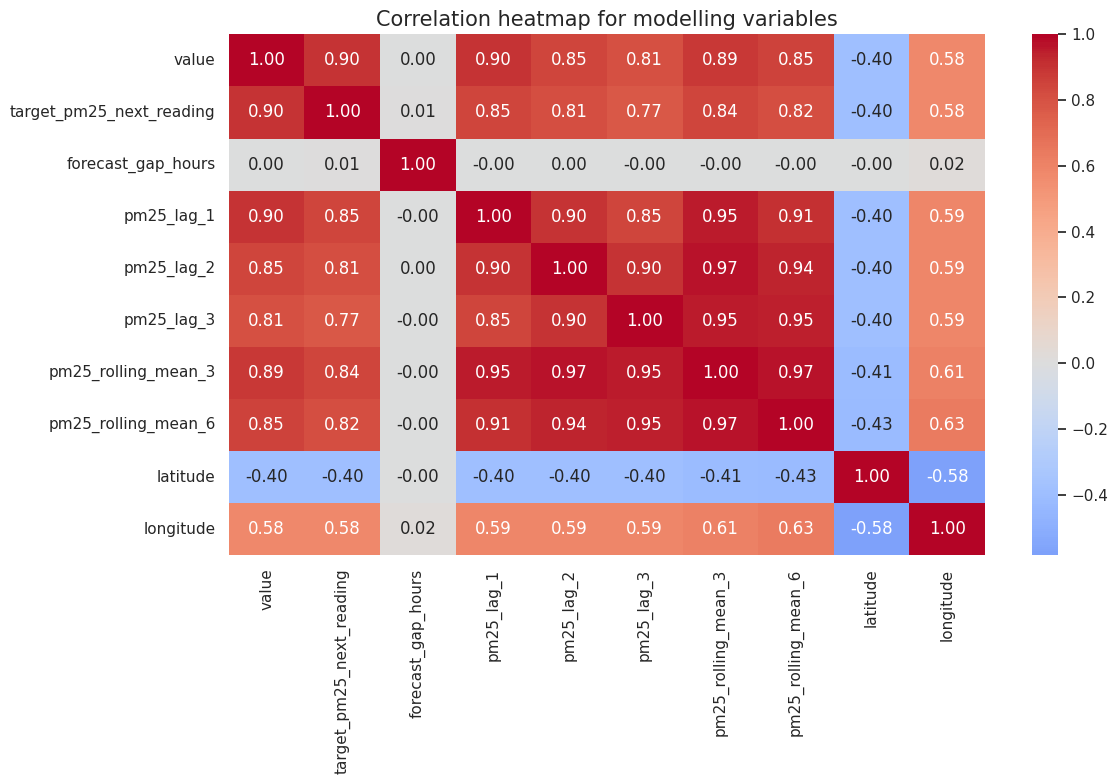

Figure saved to /kaggle/working/openaq_project_outputs/figures/22_Correlation_heatmap_for_modelling_variables.png


In [ ]:

feature_engineering_summary = pd.DataFrame({
    "metric": [
        "model_ready_rows", "stations", "cities", "countries", "start_timestamp", "end_timestamp",
        "target_mean", "target_median", "target_min", "target_max",
    ],
    "value": [
        len(model_ready_df),
        model_ready_df["station_id"].nunique(),
        model_ready_df["city"].nunique(),
        model_ready_df["country"].nunique(),
        model_ready_df["timestamp"].min(),
        model_ready_df["timestamp"].max(),
        model_ready_df["target_pm25_next_reading"].mean(),
        model_ready_df["target_pm25_next_reading"].median(),
        model_ready_df["target_pm25_next_reading"].min(),
        model_ready_df["target_pm25_next_reading"].max(),
    ],
})
display(feature_engineering_summary)

numeric_preview_columns = [
    "value", "target_pm25_next_reading", "forecast_gap_hours", "pm25_lag_1", "pm25_lag_2",
    "pm25_lag_3", "pm25_rolling_mean_3", "pm25_rolling_mean_6", "latitude", "longitude",
]
correlation_df = model_ready_df[numeric_preview_columns].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap for modelling variables")
plt.tight_layout()
show_and_save_figure()

## 9. Leakage-controlled chronological train, validation and test split

This section creates temporally separated partitions using timestamp cut-offs rather than random row splitting.

Additional safeguards:

1. `forecast_gap_hours`, `next_timestamp` and the target are **never predictors**.
2. The same timestamp cannot be split across train/validation/test.
3. High-cardinality country/city/source groupings are learned from the **training split only** and then applied unchanged to validation and test data.
4. The resulting cut-offs are reused by the CNN-LSTM experiment.


In [ ]:
TARGET_COLUMN = "target_pm25_next_reading"

# forecast_gap_hours is intentionally excluded because next_timestamp is not known at prediction time.
NUMERIC_FEATURE_COLUMNS = [
    "value", "latitude", "longitude", "averaged_over_in_hours",
    "hour", "day", "month", "weekday", "day_of_year", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "pm25_lag_1", "pm25_lag_2", "pm25_lag_3", "pm25_lag_6", "pm25_lag_12", "pm25_lag_24",
    "pm25_rolling_mean_3", "pm25_rolling_mean_6", "pm25_rolling_mean_12", "pm25_rolling_mean_24",
    "pm25_rolling_std_3", "pm25_rolling_std_6", "pm25_rolling_std_12", "pm25_rolling_std_24",
]
CATEGORICAL_FEATURE_COLUMNS = ["country_grouped", "city_grouped", "source_grouped"]
ALL_FEATURE_COLUMNS = NUMERIC_FEATURE_COLUMNS + CATEGORICAL_FEATURE_COLUMNS

LEAKAGE_EXCLUDED_COLUMNS = {TARGET_COLUMN, "next_timestamp", "forecast_gap_hours"}
assert LEAKAGE_EXCLUDED_COLUMNS.isdisjoint(ALL_FEATURE_COLUMNS), "Leakage-prone columns found in predictor list."


CATEGORY_GROUPING_SPECS = {
    "country": ("country_grouped", config.top_country_categories),
    "city": ("city_grouped", config.top_city_categories),
    "source_name": ("source_grouped", config.top_source_categories),
}


def fit_category_grouping_levels(training_dataframe: pd.DataFrame) -> Dict[str, List[str]]:
    """Learn high-cardinality grouping levels from training data only."""
    learned_levels: Dict[str, List[str]] = {}
    for raw_column, (_, top_n) in CATEGORY_GROUPING_SPECS.items():
        values = training_dataframe[raw_column].astype("string").fillna("Unknown")
        learned_levels[raw_column] = values.value_counts().head(top_n).index.astype(str).tolist()
    return learned_levels


def apply_category_grouping_levels(
    dataframe: pd.DataFrame,
    learned_levels: Dict[str, List[str]],
) -> pd.DataFrame:
    """Apply training-derived category levels to any chronological split."""
    grouped_df = dataframe.copy()
    for raw_column, (grouped_column, _) in CATEGORY_GROUPING_SPECS.items():
        values = grouped_df[raw_column].astype("string").fillna("Unknown")
        allowed_values = set(learned_levels[raw_column])
        grouped_df[grouped_column] = values.where(values.isin(allowed_values), other="Other")
    return grouped_df


split_df = model_ready_df.sort_values(["timestamp", "station_id", "model_row_id"]).reset_index(drop=True)
train_cutoff_timestamp = split_df["timestamp"].quantile(0.70)
validation_cutoff_timestamp = split_df["timestamp"].quantile(0.85)

train_df = split_df[split_df["timestamp"].le(train_cutoff_timestamp)].copy()
validation_df = split_df[
    split_df["timestamp"].gt(train_cutoff_timestamp)
    & split_df["timestamp"].le(validation_cutoff_timestamp)
].copy()
test_df = split_df[split_df["timestamp"].gt(validation_cutoff_timestamp)].copy()

if min(len(train_df), len(validation_df), len(test_df)) == 0:
    raise RuntimeError("At least one chronological split is empty. Review timestamp coverage before modelling.")

# Learn grouping levels only from training data, then freeze them.
category_grouping_levels = fit_category_grouping_levels(train_df)
train_df = apply_category_grouping_levels(train_df, category_grouping_levels)
validation_df = apply_category_grouping_levels(validation_df, category_grouping_levels)
test_df = apply_category_grouping_levels(test_df, category_grouping_levels)

available_feature_columns = [column for column in ALL_FEATURE_COLUMNS if column in train_df.columns]

X_train = train_df[available_feature_columns].copy()
y_train = train_df[TARGET_COLUMN].copy()
X_validation = validation_df[available_feature_columns].copy()
y_validation = validation_df[TARGET_COLUMN].copy()
X_test = test_df[available_feature_columns].copy()
y_test = test_df[TARGET_COLUMN].copy()

# Explicit chronological-separation checks.
assert train_df["timestamp"].max() < validation_df["timestamp"].min()
assert validation_df["timestamp"].max() < test_df["timestamp"].min()
assert "forecast_gap_hours" not in X_train.columns

split_summary_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(validation_df), len(test_df)],
    "start_timestamp": [
        train_df["timestamp"].min(),
        validation_df["timestamp"].min(),
        test_df["timestamp"].min(),
    ],
    "end_timestamp": [
        train_df["timestamp"].max(),
        validation_df["timestamp"].max(),
        test_df["timestamp"].max(),
    ],
    "target_mean": [y_train.mean(), y_validation.mean(), y_test.mean()],
    "target_median": [y_train.median(), y_validation.median(), y_test.median()],
})

display(split_summary_df)
print(f"Training cut-off timestamp:   {train_cutoff_timestamp}")
print(f"Validation cut-off timestamp: {validation_cutoff_timestamp}")
print(f"Predictor count: {len(available_feature_columns)}")
print("Leakage audit passed: future target/gap columns are not model inputs.")


,split,rows,start_timestamp,end_timestamp,target_mean,target_median
0,train,63322,2022-04-18 03:00:00+00:00,2022-04-29 11:00:00+00:00,21.502384,7.8
1,validation,13237,2022-04-29 11:15:00+00:00,2022-04-29 23:45:00+00:00,22.697978,9.0
2,test,13441,2022-04-30 00:00:00+00:00,2022-04-30 13:00:00+00:00,17.720922,8.9


Training cut-off timestamp:   2022-04-29 11:00:00+00:00
Validation cut-off timestamp: 2022-04-29 23:45:00+00:00
Predictor count: 31
Leakage audit passed: future target/gap columns are not model inputs.


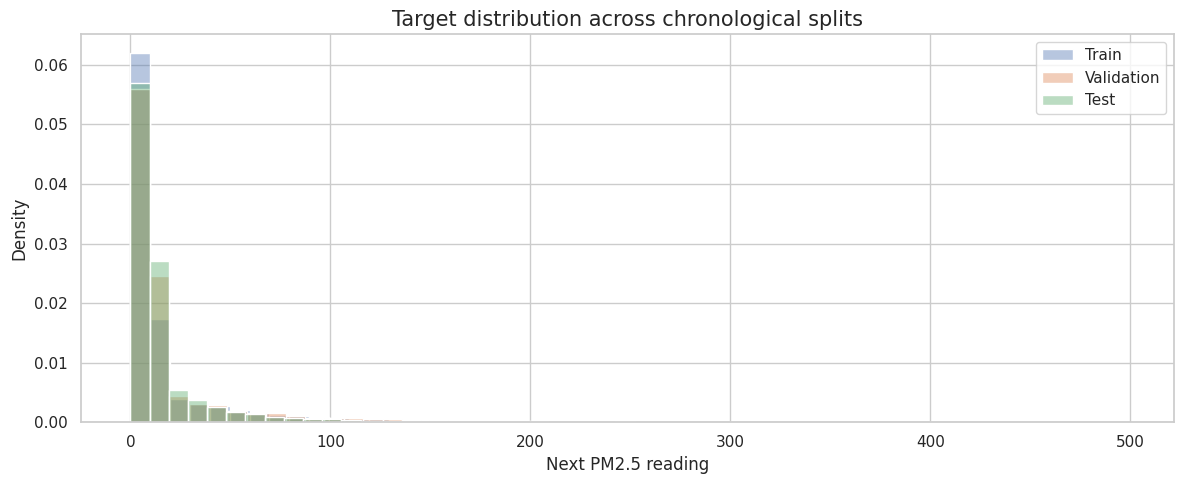

Figure saved to /kaggle/working/openaq_project_outputs/figures/23_Target_distribution_across_chronological_splits.png


In [ ]:

plt.figure(figsize=(12, 5))
sns.histplot(y_train, label="Train", bins=50, stat="density", alpha=0.4)
sns.histplot(y_validation, label="Validation", bins=50, stat="density", alpha=0.4)
sns.histplot(y_test, label="Test", bins=50, stat="density", alpha=0.4)
plt.title("Target distribution across chronological splits")
plt.xlabel("Next PM2.5 reading")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
show_and_save_figure()

## 10. Model training pipeline

The ML pipeline uses separate preprocessing for numeric and categorical features. Baseline, linear, tree-based and boosted models are compared on validation data before final test evaluation.

In [ ]:
def build_one_hot_encoder() -> OneHotEncoder:
    """Create OneHotEncoder in a version-compatible way."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(numeric_columns: List[str], categorical_columns: List[str]) -> ColumnTransformer:
    """Build preprocessing for numeric and categorical model inputs."""
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot_encoder", build_one_hot_encoder()),
    ])
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            ("categorical", categorical_pipeline, categorical_columns),
        ],
        remainder="drop",
    )


def calculate_regression_metrics(y_true: pd.Series, y_predicted: np.ndarray) -> Dict[str, float]:
    """Calculate MAE, RMSE, R² and SMAPE in a version-compatible way."""
    y_true_array = np.asarray(y_true, dtype=float)
    y_predicted_array = np.asarray(y_predicted, dtype=float)

    mae = mean_absolute_error(y_true_array, y_predicted_array)
    mse = mean_squared_error(y_true_array, y_predicted_array)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_array, y_predicted_array)
    smape = np.mean(
        2 * np.abs(y_predicted_array - y_true_array)
        / (np.abs(y_true_array) + np.abs(y_predicted_array) + 1e-8)
    ) * 100

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "SMAPE": float(smape),
    }


numeric_model_columns = [column for column in NUMERIC_FEATURE_COLUMNS if column in X_train.columns]
categorical_model_columns = [column for column in CATEGORICAL_FEATURE_COLUMNS if column in X_train.columns]
preprocessor_template = build_preprocessor(numeric_model_columns, categorical_model_columns)

print(f"Numeric features: {len(numeric_model_columns)}")
print(f"Categorical features: {len(categorical_model_columns)}")


Numeric features: 28
Categorical features: 3


In [ ]:
def build_model_candidates(project_config: ProjectConfig) -> Dict[str, object]:
    """Create candidate regression models for validation-based selection."""
    model_candidates: Dict[str, object] = {
        "Ridge Regression": Ridge(alpha=1.0, random_state=project_config.random_seed),
        "Random Forest": RandomForestRegressor(
            n_estimators=160,
            max_depth=18,
            min_samples_leaf=3,
            n_jobs=-1,
            random_state=project_config.random_seed,
        ),
        "Hist Gradient Boosting": HistGradientBoostingRegressor(
            max_iter=260,
            learning_rate=0.06,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=project_config.random_seed,
        ),
    }

    if XGBOOST_AVAILABLE:
        model_candidates["XGBoost"] = XGBRegressor(
            n_estimators=360,
            max_depth=6,
            learning_rate=0.045,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=project_config.random_seed,
            n_jobs=-1,
        )

    return model_candidates


def train_and_validate_models(
    X_train_input: pd.DataFrame,
    y_train_input: pd.Series,
    X_validation_input: pd.DataFrame,
    y_validation_input: pd.Series,
    preprocessor_object: ColumnTransformer,
    project_config: ProjectConfig,
) -> Tuple[Dict[str, Pipeline], pd.DataFrame]:
    """Train candidates on train data and rank them using validation RMSE only."""
    trained_pipelines: Dict[str, Pipeline] = {}
    metric_rows: List[Dict[str, object]] = []

    naive_validation_predictions = X_validation_input["value"].to_numpy(dtype=float)
    naive_metrics = calculate_regression_metrics(y_validation_input, naive_validation_predictions)
    metric_rows.append({"model_name": "Naive Current Value", "split": "validation", **naive_metrics})

    for model_name, model_object in build_model_candidates(project_config).items():
        print(f"Training {model_name}")
        pipeline = Pipeline(steps=[
            ("preprocessor", clone(preprocessor_object)),
            ("model", clone(model_object)),
        ])
        pipeline.fit(X_train_input, y_train_input)
        validation_predictions = pipeline.predict(X_validation_input)
        validation_metrics = calculate_regression_metrics(y_validation_input, validation_predictions)
        trained_pipelines[model_name] = pipeline
        metric_rows.append({"model_name": model_name, "split": "validation", **validation_metrics})
        print(f"{model_name} validation RMSE: {validation_metrics['RMSE']:.4f}")

    metrics_df = pd.DataFrame(metric_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
    return trained_pipelines, metrics_df


trained_ml_pipelines, validation_metrics_df = train_and_validate_models(
    X_train,
    y_train,
    X_validation,
    y_validation,
    preprocessor_template,
    config,
)
display(validation_metrics_df)


Training Ridge Regression
Ridge Regression validation RMSE: 15.4384
Training Random Forest
Random Forest validation RMSE: 14.2439
Training Hist Gradient Boosting
Hist Gradient Boosting validation RMSE: 14.7782
Training XGBoost
XGBoost validation RMSE: 14.8868


,model_name,split,MAE,RMSE,R2,SMAPE
0,Random Forest,validation,4.584162,14.243879,0.893165,24.155199
1,Hist Gradient Boosting,validation,4.751279,14.778235,0.884999,25.729828
2,XGBoost,validation,4.778447,14.886831,0.883303,25.244164
3,Ridge Regression,validation,5.217282,15.438413,0.874495,28.639897
4,Naive Current Value,validation,4.857961,16.203027,0.861755,24.559896


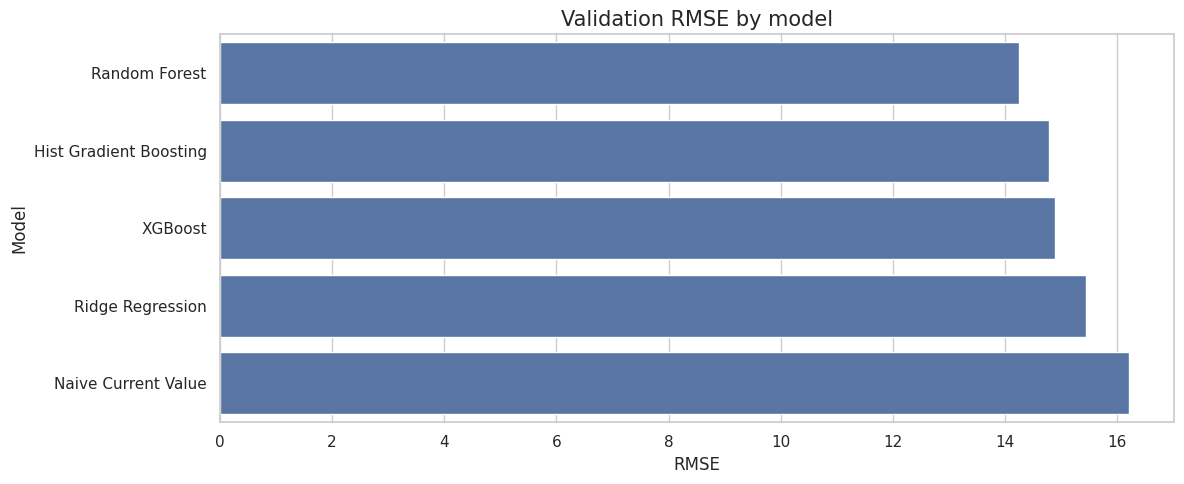

Figure saved to /kaggle/working/openaq_project_outputs/figures/24_Validation_RMSE_by_model.png


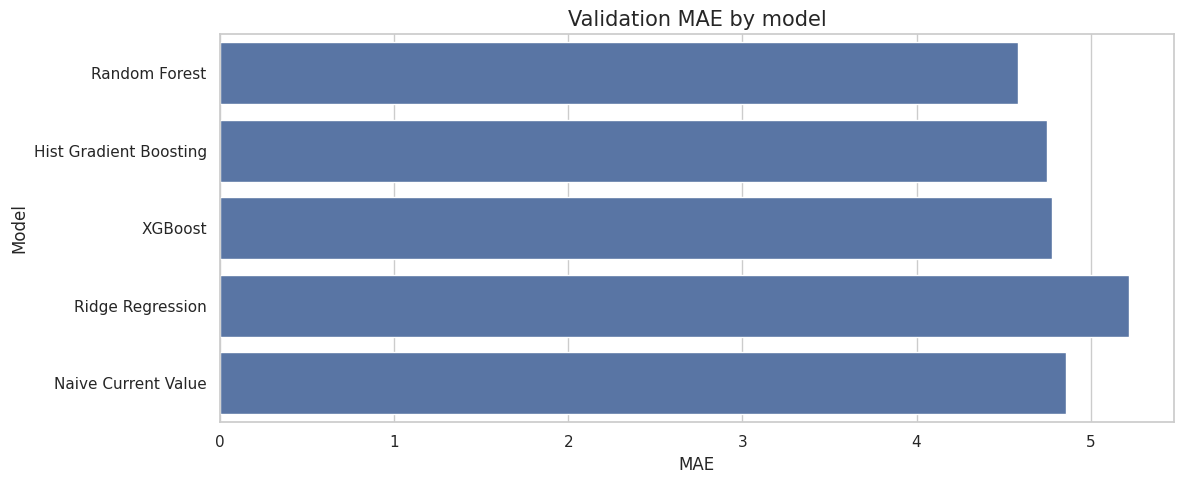

Figure saved to /kaggle/working/openaq_project_outputs/figures/25_Validation_MAE_by_model.png


In [ ]:

plt.figure(figsize=(12, 5))
sns.barplot(data=validation_metrics_df, x="RMSE", y="model_name")
plt.title("Validation RMSE by model")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
show_and_save_figure()
plt.figure(figsize=(12, 5))
sns.barplot(data=validation_metrics_df, x="MAE", y="model_name")
plt.title("Validation MAE by model")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.tight_layout()
show_and_save_figure()

## 11. Final conventional ML selection and held-out test evaluation

The final conventional ML model is selected **only from validation RMSE**. The test set is not used to choose among candidate models.

After model selection, the chosen pipeline is refitted on the combined train + validation development data and then evaluated once on the held-out chronological test set. The naive persistence baseline is also reported on test data for context.


In [ ]:
selected_model_name = str(validation_metrics_df.iloc[0]["model_name"])
selected_validation_metrics = validation_metrics_df.iloc[0].to_dict()
print(f"Model selected from validation RMSE: {selected_model_name}")

X_development = pd.concat([X_train, X_validation], axis=0)
y_development = pd.concat([y_train, y_validation], axis=0)

naive_test_predictions = X_test["value"].to_numpy(dtype=float)
naive_test_metrics = calculate_regression_metrics(y_test, naive_test_predictions)

if selected_model_name == "Naive Current Value":
    final_selected_pipeline = None
    selected_test_predictions = naive_test_predictions
else:
    # Clone the already-configured selected pipeline and refit using all development data.
    final_selected_pipeline = clone(trained_ml_pipelines[selected_model_name])
    final_selected_pipeline.fit(X_development, y_development)
    selected_test_predictions = final_selected_pipeline.predict(X_test)

selected_test_metrics = calculate_regression_metrics(y_test, selected_test_predictions)

final_test_metric_rows = [
    {"model_name": "Naive Current Value", "split": "test", **naive_test_metrics}
]
if selected_model_name != "Naive Current Value":
    final_test_metric_rows.append(
        {"model_name": selected_model_name, "split": "test", **selected_test_metrics}
    )

test_metrics_df = pd.DataFrame(final_test_metric_rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
display(test_metrics_df)

print("\nFinal held-out test metrics for the validation-selected model:")
print(json.dumps({key: round(value, 6) for key, value in selected_test_metrics.items()}, indent=2))


Model selected from validation RMSE: Random Forest


,model_name,split,MAE,RMSE,R2,SMAPE
0,Random Forest,test,4.099789,11.797660,0.850180,25.569680
1,Naive Current Value,test,4.011470,13.653122,0.799349,23.449243



Final held-out test metrics for the validation-selected model:
{
  "MAE": 4.099789,
  "RMSE": 11.79766,
  "R2": 0.85018,
  "SMAPE": 25.56968
}


In [ ]:
prediction_results_df = test_df[[
    "model_row_id",
    "timestamp",
    "next_timestamp",
    "forecast_gap_hours",
    "country",
    "city",
    "location",
    "station_id",
    "value",
    TARGET_COLUMN,
]].copy()

prediction_results_df["selected_model"] = selected_model_name
prediction_results_df["predicted_pm25_next_reading"] = selected_test_predictions
prediction_results_df["absolute_error"] = np.abs(
    prediction_results_df[TARGET_COLUMN]
    - prediction_results_df["predicted_pm25_next_reading"]
)
prediction_results_df["residual"] = (
    prediction_results_df[TARGET_COLUMN]
    - prediction_results_df["predicted_pm25_next_reading"]
)

predictions_path = Path(config.output_dir) / "test_predictions_final_selected_model.csv"
prediction_results_df.to_csv(predictions_path, index=False)
print(f"Predictions saved to {predictions_path}")
display(prediction_results_df.head())


Predictions saved to /kaggle/working/openaq_project_outputs/test_predictions_final_selected_model.csv


,model_row_id,timestamp,next_timestamp,forecast_gap_hours,country,city,location,station_id,value,target_pm25_next_reading,selected_model,predicted_pm25_next_reading,absolute_error,residual
76559,76559,2022-04-30 00:00:00+00:00,2022-04-30 02:00:00+00:00,2.0,CN,Beijing,Beijing US Embassy,CN_Beijing_Beijing US Embassy_39.95_116.47,36.0,15.0,Random Forest,45.679356,30.679356,-30.679356
76560,76560,2022-04-30 00:00:00+00:00,2022-04-30 02:00:00+00:00,2.0,CN,Guangzhou,Guangzhou,CN_Guangzhou_Guangzhou_23.12_113.32,9.0,17.0,Random Forest,11.713929,5.286071,5.286071
76561,76561,2022-04-30 00:00:00+00:00,2022-04-30 02:00:00+00:00,2.0,CN,Shanghai,Shanghai,CN_Shanghai_Shanghai_31.21_121.44,18.0,20.0,Random Forest,20.340901,0.340901,-0.340901
76562,76562,2022-04-30 00:00:00+00:00,2022-04-30 02:00:00+00:00,2.0,GB,Auchencorth,Auchencorth Moss,GB_Auchencorth_Auchencorth Moss_55.792_-3.243,7.0,8.0,Random Forest,7.108351,0.891649,0.891649
76563,76563,2022-04-30 00:00:00+00:00,2022-04-30 02:00:00+00:00,2.0,GB,Belfast,Belfast Centre,GB_Belfast_Belfast Centre_54.6_-5.929,17.0,18.0,Random Forest,16.383690,1.616310,1.616310


Metrics saved to /kaggle/working/openaq_project_outputs/model_metrics.csv


,model_name,split,MAE,RMSE,R2,SMAPE
0,Random Forest,validation,4.584162,14.243879,0.893165,24.155199
1,Hist Gradient Boosting,validation,4.751279,14.778235,0.884999,25.729828
2,XGBoost,validation,4.778447,14.886831,0.883303,25.244164
3,Ridge Regression,validation,5.217282,15.438413,0.874495,28.639897
4,Naive Current Value,validation,4.857961,16.203027,0.861755,24.559896
5,Random Forest,test,4.099789,11.797660,0.850180,25.569680
6,Naive Current Value,test,4.011470,13.653122,0.799349,23.449243


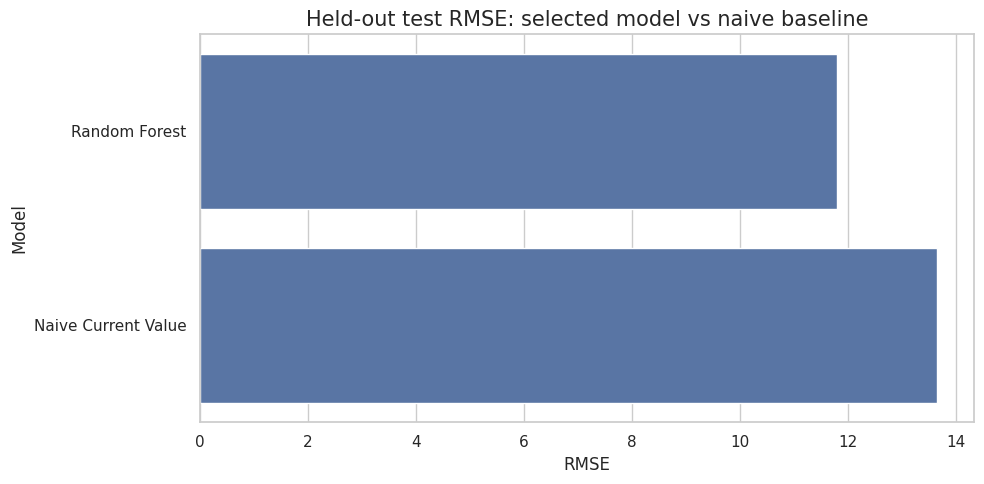

Figure saved to /kaggle/working/openaq_project_outputs/figures/26_Held-out_test_RMSE_selected_model_vs_naive_baseline.png


In [ ]:
metrics_export_df = pd.concat(
    [validation_metrics_df, test_metrics_df],
    ignore_index=True,
)
metrics_path = Path(config.output_dir) / "model_metrics.csv"
metrics_export_df.to_csv(metrics_path, index=False)
print(f"Metrics saved to {metrics_path}")
display(metrics_export_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=test_metrics_df, x="RMSE", y="model_name")
plt.title("Held-out test RMSE: selected model vs naive baseline")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
show_and_save_figure()


## 12. Final model evaluation visualisations

The following diagnostics use the **validation-selected final model** only. They assess overall predictive quality, residual behaviour and geographic heterogeneity without changing the model-selection decision.


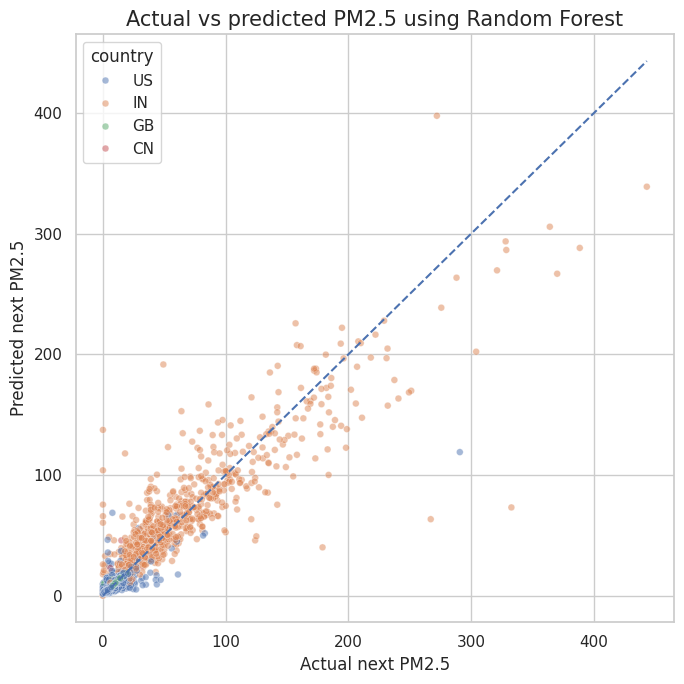

Figure saved to /kaggle/working/openaq_project_outputs/figures/27_Actual_vs_predicted_PM2_5_using_Random_Forest.png


In [ ]:

plot_sample_df = prediction_results_df.sample(min(len(prediction_results_df), 5_000), random_state=config.random_seed)

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=plot_sample_df,
    x=TARGET_COLUMN,
    y="predicted_pm25_next_reading",
    hue="country",
    alpha=0.5,
    s=24,
)
axis_min = min(plot_sample_df[TARGET_COLUMN].min(), plot_sample_df["predicted_pm25_next_reading"].min())
axis_max = max(plot_sample_df[TARGET_COLUMN].max(), plot_sample_df["predicted_pm25_next_reading"].max())
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
plt.title(f"Actual vs predicted PM2.5 using {selected_model_name}")
plt.xlabel("Actual next PM2.5")
plt.ylabel("Predicted next PM2.5")
plt.tight_layout()
show_and_save_figure()

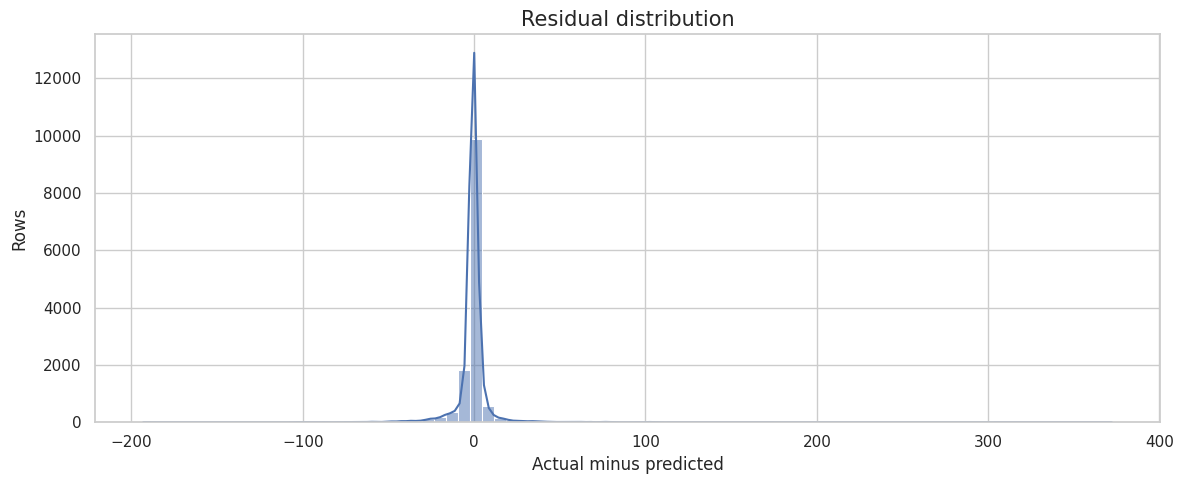

Figure saved to /kaggle/working/openaq_project_outputs/figures/28_Residual_distribution.png


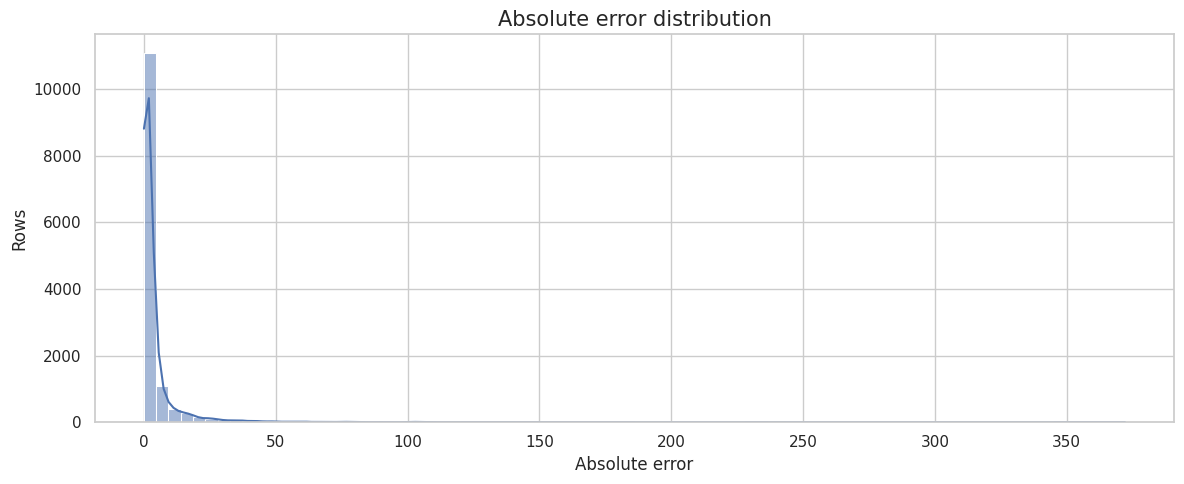

Figure saved to /kaggle/working/openaq_project_outputs/figures/29_Absolute_error_distribution.png


In [ ]:

plt.figure(figsize=(12, 5))
sns.histplot(prediction_results_df["residual"], bins=80, kde=True)
plt.title("Residual distribution")
plt.xlabel("Actual minus predicted")
plt.ylabel("Rows")
plt.tight_layout()
show_and_save_figure()
plt.figure(figsize=(12, 5))
sns.histplot(prediction_results_df["absolute_error"], bins=80, kde=True)
plt.title("Absolute error distribution")
plt.xlabel("Absolute error")
plt.ylabel("Rows")
plt.tight_layout()
show_and_save_figure()

,country,row_count,mae,median_absolute_error,p90_absolute_error
0,IN,2693,13.473025,6.974591,31.130041
1,CN,36,6.162405,3.616849,16.324022
2,US,9746,1.831022,1.108097,3.791212
3,GB,966,0.782000,0.480007,1.653017


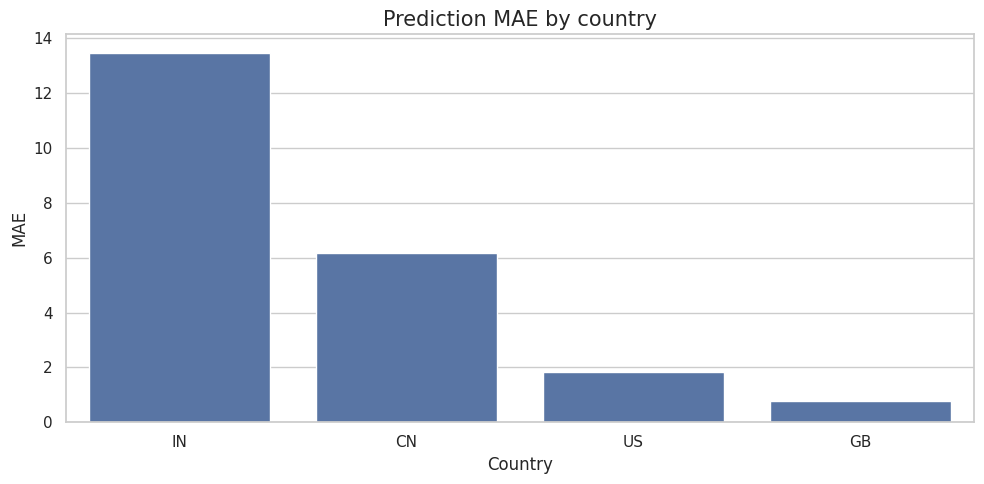

Figure saved to /kaggle/working/openaq_project_outputs/figures/30_Prediction_MAE_by_country.png


In [ ]:

error_by_country_df = (
    prediction_results_df.groupby("country")
    .agg(
        row_count=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        p90_absolute_error=("absolute_error", lambda series: np.percentile(series, 90)),
    )
    .sort_values("mae", ascending=False)
    .reset_index()
)
display(error_by_country_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=error_by_country_df, x="country", y="mae")
plt.title("Prediction MAE by country")
plt.xlabel("Country")
plt.ylabel("MAE")
plt.tight_layout()
show_and_save_figure()

In [ ]:

error_by_city_df = (
    prediction_results_df.groupby(["country", "city"])
    .agg(row_count=("absolute_error", "size"), mae=("absolute_error", "mean"))
    .query("row_count >= 20")
    .sort_values("mae", ascending=False)
    .head(20)
    .reset_index()
)
display(error_by_city_df)

plt.figure(figsize=(12, 7))
sns.barplot(data=error_by_city_df, x="mae", y="city", hue="country", dodge=False)
plt.title("Cities with highest prediction MAE")
plt.xlabel("MAE")
plt.ylabel("City")
plt.tight_layout()
show_and_save_figure()

,country,city,row_count,mae
0,IN,Ghaziabad,33,32.609070
1,US,STEVENS,22,31.226144
2,IN,Kanpur,40,25.413722
3,IN,Delhi,315,25.331783
4,IN,Meerut,28,23.083426
5,IN,Noida,23,22.072497
6,IN,Patna,57,20.687505
7,IN,Jaipur,29,18.719208
8,IN,Gurugram,28,18.709375
9,IN,Greater Noida,21,17.734255


In [ ]:

time_plot_df = prediction_results_df.sort_values("timestamp").copy().tail(500)

plt.figure(figsize=(14, 6))
plt.plot(time_plot_df["timestamp"], time_plot_df[TARGET_COLUMN], label="Actual")
plt.plot(time_plot_df["timestamp"], time_plot_df["predicted_pm25_next_reading"], label="Predicted")
plt.title("Actual and predicted PM2.5 over the final test window")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
show_and_save_figure()

## 13. CNN-LSTM deep-learning experiment with matched temporal boundaries

The CNN-LSTM uses station-wise sequences ending at the current observation and predicts that row's next available PM2.5 target.

Safeguards in this final version:

- sequence inputs exclude `forecast_gap_hours` and all future-derived fields;
- the current observation is included as the final sequence step;
- sequences are split using the **same train/validation/test timestamp cut-offs** as the conventional ML workflow;
- scaling parameters are fitted on the CNN-LSTM training sequences only;
- an additional common-subset table compares CNN-LSTM, the selected ML model and the naive baseline on **exactly the same test rows**.


In [ ]:
SEQUENCE_FEATURE_COLUMNS = [
    "value",
    "latitude",
    "longitude",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "is_weekend",
]


def create_station_sequences(
    dataframe: pd.DataFrame,
    sequence_length: int,
    sample_limit: int,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Create chronological station sequences using only information available by the prediction origin."""
    sequence_source_df = dataframe.sort_values(["timestamp", "station_id", "model_row_id"]).copy()

    if len(sequence_source_df) > sample_limit:
        sequence_source_df = sequence_source_df.tail(sample_limit).copy()

    required_sequence_columns = SEQUENCE_FEATURE_COLUMNS + [TARGET_COLUMN, "timestamp", "model_row_id"]
    sequence_source_df = sequence_source_df.replace([np.inf, -np.inf], np.nan)
    sequence_source_df = sequence_source_df.dropna(subset=required_sequence_columns).copy()

    feature_sequences: List[np.ndarray] = []
    target_values: List[float] = []
    sequence_rows: List[Dict[str, object]] = []

    for station_id, station_df in sequence_source_df.groupby("station_id", sort=False):
        station_df = station_df.sort_values(["timestamp", "model_row_id"]).reset_index(drop=True)
        if len(station_df) < sequence_length:
            continue

        station_features = station_df[SEQUENCE_FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        station_targets = station_df[TARGET_COLUMN].to_numpy(dtype=np.float32)
        metadata_columns = [
            "model_row_id", "timestamp", "next_timestamp", "forecast_gap_hours",
            "country", "city", "location", "station_id", TARGET_COLUMN,
        ]
        station_metadata = station_df[metadata_columns]

        # The sequence ends at the current row, whose next-reading target is being predicted.
        for current_position in range(sequence_length - 1, len(station_df)):
            start_position = current_position - sequence_length + 1
            feature_sequences.append(station_features[start_position: current_position + 1])
            target_values.append(station_targets[current_position])
            sequence_rows.append(station_metadata.iloc[current_position].to_dict())

    if not feature_sequences:
        return (
            np.empty((0, sequence_length, len(SEQUENCE_FEATURE_COLUMNS)), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            pd.DataFrame(),
        )

    X_sequence = np.asarray(feature_sequences, dtype=np.float32)
    y_sequence = np.asarray(target_values, dtype=np.float32)
    metadata_df = pd.DataFrame(sequence_rows)
    metadata_df["timestamp"] = pd.to_datetime(metadata_df["timestamp"], utc=True)

    # Globally sort sequences by prediction-origin timestamp.
    chronological_order = np.argsort(metadata_df["timestamp"].astype("int64").to_numpy())
    X_sequence = X_sequence[chronological_order]
    y_sequence = y_sequence[chronological_order]
    metadata_df = metadata_df.iloc[chronological_order].reset_index(drop=True)

    return X_sequence, y_sequence, metadata_df


if config.enable_deep_learning and TENSORFLOW_AVAILABLE and len(model_ready_df) >= config.sequence_length:
    X_sequence, y_sequence, sequence_metadata_df = create_station_sequences(
        model_ready_df,
        sequence_length=config.sequence_length,
        sample_limit=config.deep_learning_sample_limit,
    )
    print(f"Sequence tensor shape: {X_sequence.shape}")
    print(f"Sequence target shape: {y_sequence.shape}")
    if not sequence_metadata_df.empty:
        print(
            "Sequence timestamp coverage: "
            f"{sequence_metadata_df['timestamp'].min()} to {sequence_metadata_df['timestamp'].max()}"
        )
else:
    X_sequence = np.empty((0, config.sequence_length, len(SEQUENCE_FEATURE_COLUMNS)), dtype=np.float32)
    y_sequence = np.empty((0,), dtype=np.float32)
    sequence_metadata_df = pd.DataFrame()
    print("Deep-learning sequence creation skipped.")


Sequence tensor shape: (75465, 12, 8)
Sequence target shape: (75465,)
Sequence timestamp coverage: 2022-04-19 03:00:00+00:00 to 2022-04-30 13:00:00+00:00


In [ ]:
def train_cnn_lstm_model(
    X_sequence_input: np.ndarray,
    y_sequence_input: np.ndarray,
    sequence_metadata_input: pd.DataFrame,
    train_cutoff: pd.Timestamp,
    validation_cutoff: pd.Timestamp,
    project_config: ProjectConfig,
):
    """Train CNN-LSTM using the same chronological cut-offs as the conventional ML experiment."""
    if not TENSORFLOW_AVAILABLE or len(X_sequence_input) < 500 or sequence_metadata_input.empty:
        print("CNN-LSTM skipped because TensorFlow is unavailable or sequence count is too small.")
        return None, None, None, None, pd.DataFrame(), None

    sequence_times = pd.to_datetime(sequence_metadata_input["timestamp"], utc=True)
    train_mask = sequence_times.le(train_cutoff).to_numpy()
    validation_mask = (
        sequence_times.gt(train_cutoff) & sequence_times.le(validation_cutoff)
    ).to_numpy()
    test_mask = sequence_times.gt(validation_cutoff).to_numpy()

    split_counts = {
        "train": int(train_mask.sum()),
        "validation": int(validation_mask.sum()),
        "test": int(test_mask.sum()),
    }
    print(f"CNN-LSTM chronological split counts: {split_counts}")

    if min(split_counts.values()) < 50:
        print("CNN-LSTM skipped because one temporal partition contains too few sequences.")
        return None, None, None, None, pd.DataFrame(), None

    X_seq_train = X_sequence_input[train_mask]
    y_seq_train = y_sequence_input[train_mask]
    X_seq_validation = X_sequence_input[validation_mask]
    y_seq_validation = y_sequence_input[validation_mask]
    X_seq_test = X_sequence_input[test_mask]
    y_seq_test = y_sequence_input[test_mask]
    test_metadata = sequence_metadata_input.loc[test_mask].reset_index(drop=True).copy()

    # Fit scaling on training sequences only.
    feature_mean = X_seq_train.mean(axis=(0, 1), keepdims=True)
    feature_std = X_seq_train.std(axis=(0, 1), keepdims=True) + 1e-6

    X_seq_train_scaled = (X_seq_train - feature_mean) / feature_std
    X_seq_validation_scaled = (X_seq_validation - feature_mean) / feature_std
    X_seq_test_scaled = (X_seq_test - feature_mean) / feature_std

    model = keras.Sequential([
        layers.Input(shape=(X_seq_train_scaled.shape[1], X_seq_train_scaled.shape[2])),
        layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal"),
        layers.Dropout(0.15),
        layers.LSTM(48, return_sequences=False),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(1),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"],
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    )

    history = model.fit(
        X_seq_train_scaled,
        y_seq_train,
        validation_data=(X_seq_validation_scaled, y_seq_validation),
        epochs=20,
        batch_size=256,
        callbacks=[early_stopping, reduce_lr],
        verbose=1,
    )

    test_predictions = model.predict(X_seq_test_scaled, verbose=0).ravel()
    history_df = pd.DataFrame(history.history)
    scaling_artifacts = {
        "feature_mean": feature_mean,
        "feature_std": feature_std,
        "feature_columns": SEQUENCE_FEATURE_COLUMNS,
    }

    return model, history_df, y_seq_test, test_predictions, test_metadata, scaling_artifacts


(
    cnn_lstm_model,
    cnn_lstm_history_df,
    cnn_lstm_y_test,
    cnn_lstm_test_predictions,
    cnn_lstm_test_metadata_df,
    cnn_lstm_scaling_artifacts,
) = train_cnn_lstm_model(
    X_sequence,
    y_sequence,
    sequence_metadata_df,
    train_cutoff_timestamp,
    validation_cutoff_timestamp,
    config,
)

if cnn_lstm_history_df is not None:
    display(cnn_lstm_history_df.tail())


CNN-LSTM chronological split counts: {'train': 48798, 'validation': 13228, 'test': 13439}
Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1402.4343 - mae: 13.9328 - val_loss: 864.2958 - val_mae: 9.3225 - learning_rate: 0.0010
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 543.7960 - mae: 7.5473 - val_loss: 421.0000 - val_mae: 6.3654 - learning_rate: 0.0010
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 329.8454 - mae: 6.2968 - val_loss: 298.3950 - val_mae: 5.8336 - learning_rate: 0.0010
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 268.8169 - mae: 5.8889 - val_loss: 255.4974 - val_mae: 5.4630 - learning_rate: 0.0010
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 243.5642 - mae: 5.6311 - val_loss: 239.1896 - val_mae: 5.3047 - learning_rate: 0.0010
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 230.1474 - mae: 5.5189 - val_loss: 227.2089 - val_mae: 5.1634 - learning_rate: 0.0010
Epoch 7/20
191/191 ━━━━━━━━━━━━

,loss,mae,val_loss,val_mae,learning_rate
15,206.791000,5.163500,209.321030,5.003460,0.00050
16,203.814651,5.148133,207.648422,4.976262,0.00050
17,203.799484,5.137285,213.759827,5.037715,0.00050
18,201.684494,5.125057,210.727341,4.913683,0.00050
19,202.274872,5.066733,209.401566,4.864161,0.00025


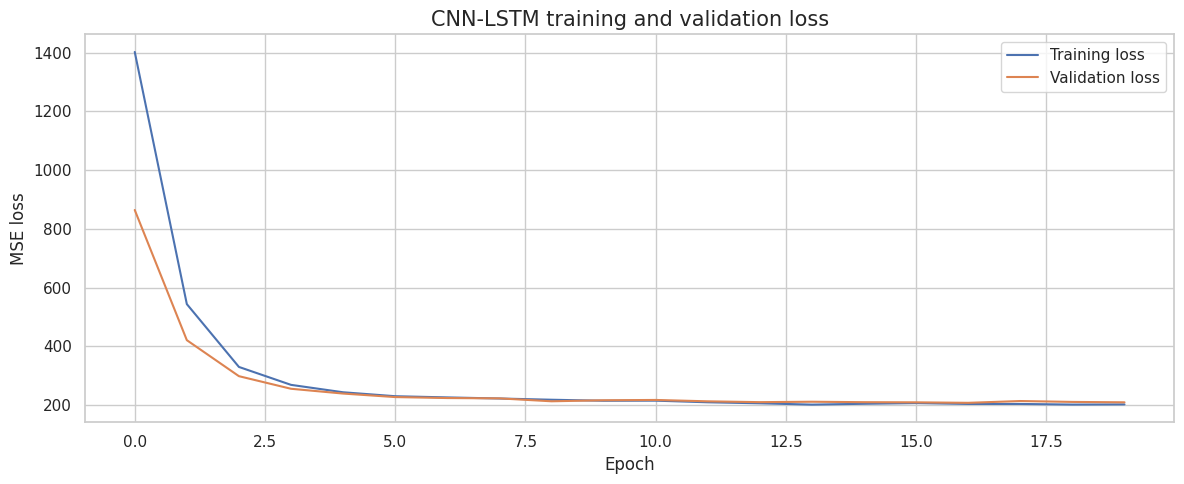

Figure saved to /kaggle/working/openaq_project_outputs/figures/33_CNN-LSTM_training_and_validation_loss.png


,model_name,split,MAE,RMSE,R2,SMAPE
0,CNN-LSTM,test_sequence_subset,7.352811,14.493048,0.773895,64.411758


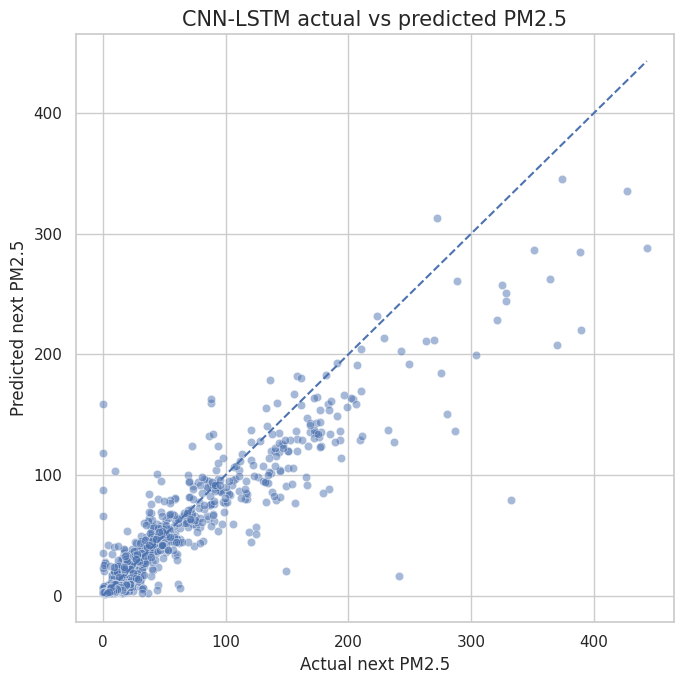

Figure saved to /kaggle/working/openaq_project_outputs/figures/34_CNN-LSTM_actual_vs_predicted_PM2_5.png
Direct model comparison on the identical CNN-LSTM test subset:


,model_name,MAE,RMSE,R2,SMAPE
0,Random Forest,4.098782,11.797712,0.850174,25.570557
1,Naive Current Value,4.011025,13.653822,0.799322,23.450761
2,CNN-LSTM,7.352811,14.493047,0.773895,64.411758


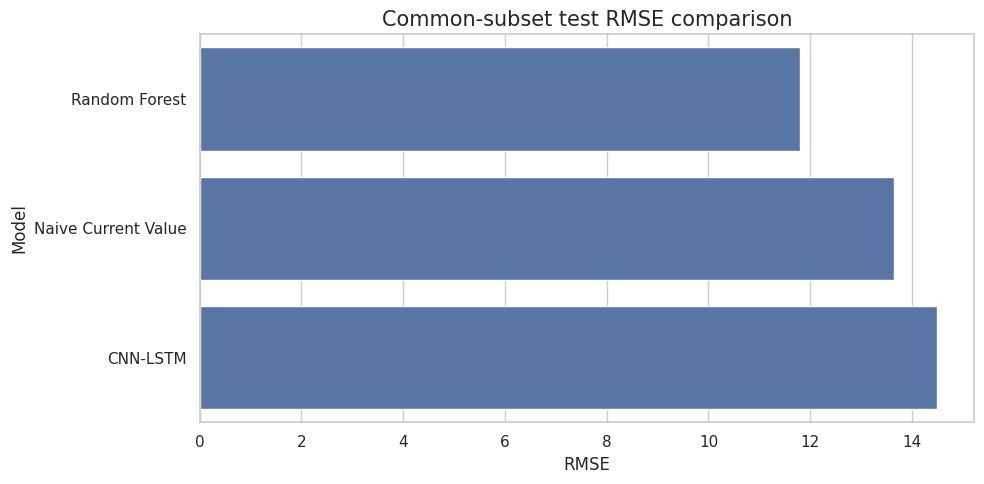

Figure saved to /kaggle/working/openaq_project_outputs/figures/35_Common-subset_test_RMSE_comparison.png
CNN-LSTM common-test predictions saved to /kaggle/working/openaq_project_outputs/cnn_lstm_common_test_predictions.csv


In [ ]:
common_test_comparison_df = pd.DataFrame()
cnn_lstm_prediction_results_df = pd.DataFrame()

if cnn_lstm_history_df is not None:
    plt.figure(figsize=(12, 5))
    plt.plot(cnn_lstm_history_df["loss"], label="Training loss")
    plt.plot(cnn_lstm_history_df["val_loss"], label="Validation loss")
    plt.title("CNN-LSTM training and validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.tight_layout()
    show_and_save_figure()

    cnn_lstm_metrics = calculate_regression_metrics(cnn_lstm_y_test, cnn_lstm_test_predictions)
    cnn_lstm_metrics_df = pd.DataFrame([
        {"model_name": "CNN-LSTM", "split": "test_sequence_subset", **cnn_lstm_metrics}
    ])
    display(cnn_lstm_metrics_df)

    plt.figure(figsize=(7, 7))
    visual_limit = min(3000, len(cnn_lstm_y_test))
    sns.scatterplot(
        x=cnn_lstm_y_test[:visual_limit],
        y=cnn_lstm_test_predictions[:visual_limit],
        alpha=0.5,
    )
    dl_axis_min = min(
        float(np.min(cnn_lstm_y_test[:visual_limit])),
        float(np.min(cnn_lstm_test_predictions[:visual_limit])),
    )
    dl_axis_max = max(
        float(np.max(cnn_lstm_y_test[:visual_limit])),
        float(np.max(cnn_lstm_test_predictions[:visual_limit])),
    )
    plt.plot([dl_axis_min, dl_axis_max], [dl_axis_min, dl_axis_max], linestyle="--")
    plt.title("CNN-LSTM actual vs predicted PM2.5")
    plt.xlabel("Actual next PM2.5")
    plt.ylabel("Predicted next PM2.5")
    plt.tight_layout()
    show_and_save_figure()

    # Align the final conventional ML model to exactly the same test rows as the CNN-LSTM.
    common_row_ids = cnn_lstm_test_metadata_df["model_row_id"].astype(np.int64).tolist()
    common_test_df = (
        test_df.set_index("model_row_id", drop=False)
        .loc[common_row_ids]
        .reset_index(drop=True)
    )

    common_y_test = common_test_df[TARGET_COLUMN].to_numpy(dtype=float)
    np.testing.assert_allclose(
        common_y_test,
        np.asarray(cnn_lstm_y_test, dtype=float),
        rtol=1e-5,
        atol=1e-5,
    )

    common_naive_predictions = common_test_df["value"].to_numpy(dtype=float)
    if final_selected_pipeline is None:
        common_ml_predictions = common_naive_predictions
    else:
        common_ml_predictions = final_selected_pipeline.predict(
            common_test_df[available_feature_columns]
        )

    common_test_comparison_df = pd.DataFrame([
        {
            "model_name": "Naive Current Value",
            **calculate_regression_metrics(common_y_test, common_naive_predictions),
        },
        {
            "model_name": selected_model_name,
            **calculate_regression_metrics(common_y_test, common_ml_predictions),
        },
        {
            "model_name": "CNN-LSTM",
            **calculate_regression_metrics(common_y_test, cnn_lstm_test_predictions),
        },
    ]).drop_duplicates(subset=["model_name"]).sort_values("RMSE").reset_index(drop=True)

    print("Direct model comparison on the identical CNN-LSTM test subset:")
    display(common_test_comparison_df)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=common_test_comparison_df, x="RMSE", y="model_name")
    plt.title("Common-subset test RMSE comparison")
    plt.xlabel("RMSE")
    plt.ylabel("Model")
    plt.tight_layout()
    show_and_save_figure()

    cnn_lstm_prediction_results_df = cnn_lstm_test_metadata_df.copy()
    cnn_lstm_prediction_results_df["actual_pm25_next_reading"] = common_y_test
    cnn_lstm_prediction_results_df["cnn_lstm_prediction"] = cnn_lstm_test_predictions
    cnn_lstm_prediction_results_df["selected_ml_prediction"] = common_ml_predictions
    cnn_lstm_prediction_results_df["naive_prediction"] = common_naive_predictions

    cnn_prediction_path = Path(config.output_dir) / "cnn_lstm_common_test_predictions.csv"
    cnn_lstm_prediction_results_df.to_csv(cnn_prediction_path, index=False)
    print(f"CNN-LSTM common-test predictions saved to {cnn_prediction_path}")
else:
    cnn_lstm_metrics_df = pd.DataFrame()
    cnn_lstm_scaling_artifacts = None
    print("CNN-LSTM evaluation skipped.")


## 14. Explainability and feature importance

Explainability is performed on the final validation-selected conventional ML model. SHAP is attempted first for tree-based models; if it is unavailable or incompatible, permutation importance provides a transparent fallback.

The analysis is post-hoc and does not alter model selection.


,feature,importance
0,value,11.217921
1,pm25_rolling_mean_12,4.058773
2,pm25_rolling_mean_24,3.675189
3,pm25_lag_1,0.805138
4,hour_sin,0.513236
5,pm25_rolling_mean_6,0.420769
6,pm25_lag_24,0.385089
7,pm25_rolling_mean_3,0.312915
8,pm25_lag_6,0.254518
9,pm25_lag_3,0.212317


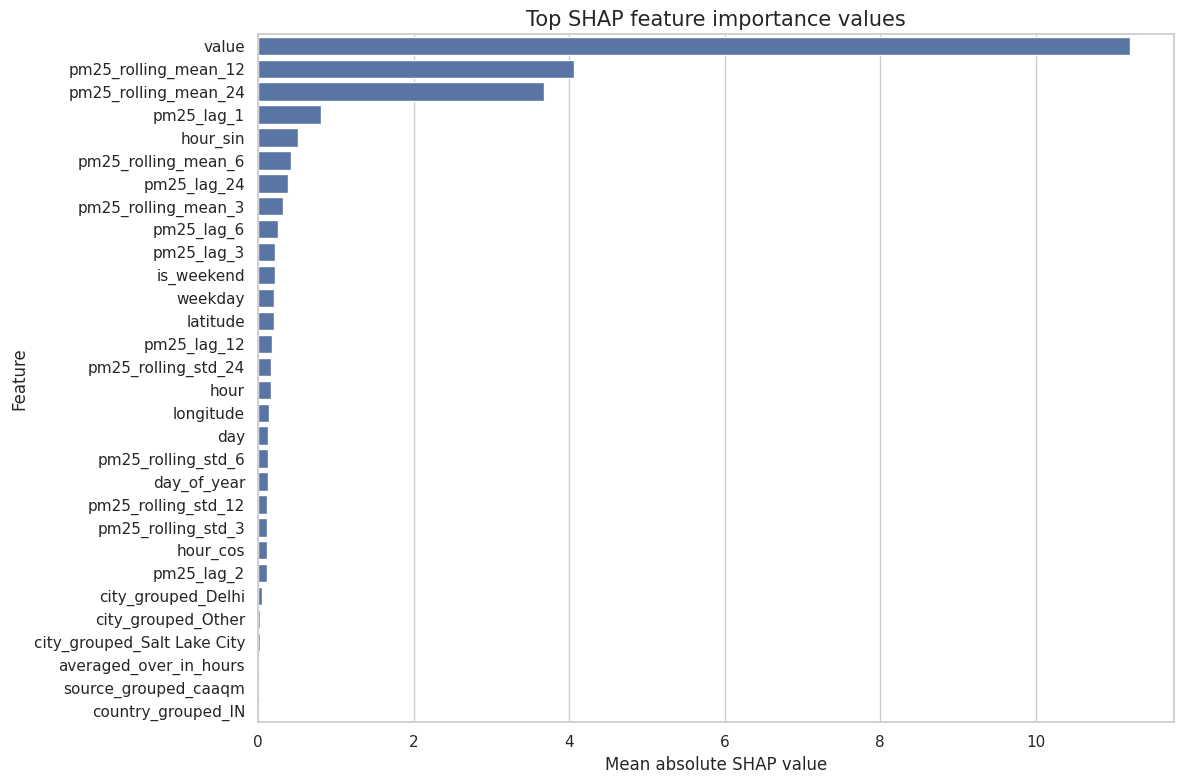

Figure saved to /kaggle/working/openaq_project_outputs/figures/36_Top_SHAP_feature_importance_values.png
Feature importance saved to /kaggle/working/openaq_project_outputs/feature_importance.csv


In [ ]:
def get_preprocessed_feature_names(
    fitted_pipeline: Pipeline,
    numeric_columns: List[str],
    categorical_columns: List[str],
) -> List[str]:
    """Extract transformed feature names from a fitted preprocessing pipeline."""
    preprocessor_object = fitted_pipeline.named_steps["preprocessor"]
    feature_names = list(numeric_columns)

    try:
        categorical_encoder = (
            preprocessor_object
            .named_transformers_["categorical"]
            .named_steps["one_hot_encoder"]
        )
        categorical_names = categorical_encoder.get_feature_names_out(categorical_columns).tolist()
        feature_names.extend(categorical_names)
    except Exception:
        feature_names.extend(categorical_columns)

    return feature_names


def run_feature_importance_analysis(
    fitted_pipeline: Optional[Pipeline],
    X_analysis_input: pd.DataFrame,
    y_analysis_input: pd.Series,
    project_config: ProjectConfig,
) -> pd.DataFrame:
    """Run SHAP where possible, otherwise permutation importance."""
    if fitted_pipeline is None:
        print("Feature importance skipped because the selected model is the naive baseline.")
        return pd.DataFrame()

    analysis_sample_size = min(len(X_analysis_input), 1_000)
    X_importance_sample = X_analysis_input.sample(
        analysis_sample_size,
        random_state=project_config.random_seed,
    )
    y_importance_sample = y_analysis_input.loc[X_importance_sample.index]

    if project_config.enable_shap:
        try:
            import shap

            transformed_features = fitted_pipeline.named_steps["preprocessor"].transform(X_importance_sample)
            feature_names = get_preprocessed_feature_names(
                fitted_pipeline,
                numeric_model_columns,
                categorical_model_columns,
            )
            fitted_model = fitted_pipeline.named_steps["model"]
            shap_sample_size = min(transformed_features.shape[0], 300)
            shap_input = transformed_features[:shap_sample_size]

            # TreeExplainer is fast for RF/XGBoost; disable additivity checking to avoid harmless
            # floating-point additivity failures observed in some sklearn/SHAP combinations.
            try:
                tree_explainer = shap.TreeExplainer(fitted_model)
                shap_values = tree_explainer.shap_values(shap_input, check_additivity=False)
                shap_array = np.asarray(shap_values)
                if shap_array.ndim == 3:
                    shap_array = shap_array[0]
            except Exception:
                generic_explainer = shap.Explainer(fitted_model, shap_input)
                generic_values = generic_explainer(shap_input)
                shap_array = np.asarray(generic_values.values)

            mean_abs_shap = np.abs(shap_array).mean(axis=0)
            usable_feature_count = min(len(feature_names), len(mean_abs_shap))
            shap_importance_df = (
                pd.DataFrame({
                    "feature": feature_names[:usable_feature_count],
                    "importance": mean_abs_shap[:usable_feature_count],
                })
                .sort_values("importance", ascending=False)
                .head(30)
                .reset_index(drop=True)
            )
            display(shap_importance_df)

            plt.figure(figsize=(12, 8))
            sns.barplot(data=shap_importance_df, x="importance", y="feature")
            plt.title("Top SHAP feature importance values")
            plt.xlabel("Mean absolute SHAP value")
            plt.ylabel("Feature")
            plt.tight_layout()
            show_and_save_figure()
            return shap_importance_df
        except Exception as shap_error:
            print(f"SHAP analysis skipped; using permutation importance instead: {shap_error}")

    print("Running permutation importance fallback")
    permutation_result = permutation_importance(
        fitted_pipeline,
        X_importance_sample,
        y_importance_sample,
        n_repeats=5,
        random_state=project_config.random_seed,
        n_jobs=-1,
        scoring="neg_root_mean_squared_error",
    )
    importance_df = (
        pd.DataFrame({
            "feature": X_importance_sample.columns,
            "importance": permutation_result.importances_mean,
            "importance_std": permutation_result.importances_std,
        })
        .sort_values("importance", ascending=False)
        .head(30)
        .reset_index(drop=True)
    )
    display(importance_df)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title("Top permutation importance values")
    plt.xlabel("Increase in RMSE when feature is permuted")
    plt.ylabel("Feature")
    plt.tight_layout()
    show_and_save_figure()
    return importance_df


importance_df = run_feature_importance_analysis(
    final_selected_pipeline,
    X_test,
    y_test,
    config,
)

if not importance_df.empty:
    importance_path = Path(config.output_dir) / "feature_importance.csv"
    importance_df.to_csv(importance_path, index=False)
    print(f"Feature importance saved to {importance_path}")


## 15. Save final artefacts

The final reproducibility artefacts are saved under `/kaggle/working/openaq_project_outputs`.

They include cleaned/model-ready data, split summaries, validation/test metrics, final predictions, error tables, category-grouping levels, the final conventional ML pipeline, CNN-LSTM artefacts where available, an interactive station map, explainability output and exported PNG figures.


In [ ]:
# Export tabular diagnostics used in the report.
split_summary_df.to_csv(Path(config.output_dir) / "chronological_split_summary.csv", index=False)
error_by_country_df.to_csv(Path(config.output_dir) / "error_by_country.csv", index=False)
error_by_city_df.to_csv(Path(config.output_dir) / "error_by_city.csv", index=False)

if not common_test_comparison_df.empty:
    common_test_comparison_df.to_csv(
        Path(config.output_dir) / "common_test_model_comparison.csv",
        index=False,
    )

category_levels_path = Path(config.output_dir) / "training_category_grouping_levels.json"
with open(category_levels_path, "w", encoding="utf-8") as category_file:
    json.dump(category_grouping_levels, category_file, indent=2)

summary_report = {
    "project_name": config.project_name,
    "dataset_source": "OpenAQ through attached Kaggle CSV or optional BigQuery fallback",
    "bigquery_table": f"{config.bigquery_project}.{config.bigquery_dataset}.{config.bigquery_table}",
    "urec_scope": "Secondary environmental sensor data only; no human participants or primary data collection.",
    "forecast_definition": (
        "Predict the next available station-level PM2.5 reading. "
        f"Observed next-reading gap must be >0 and <= {config.maximum_forecast_gap_hours} hours; "
        "forecast_gap_hours is audit-only and excluded from predictors."
    ),
    "raw_rows": int(len(raw_air_quality_df)),
    "clean_rows": int(len(clean_air_quality_df)),
    "pm25_rows": int(len(pm25_df)),
    "model_ready_rows": int(len(model_ready_df)),
    "train_cutoff_timestamp": str(train_cutoff_timestamp),
    "validation_cutoff_timestamp": str(validation_cutoff_timestamp),
    "selected_model_from_validation": selected_model_name,
    "selected_validation_metrics": {
        key: float(selected_validation_metrics[key])
        for key in ["MAE", "RMSE", "R2", "SMAPE"]
        if key in selected_validation_metrics
    },
    "final_selected_test_metrics": selected_test_metrics,
    "cnn_lstm_test_metrics": (
        cnn_lstm_metrics_df.iloc[0][["MAE", "RMSE", "R2", "SMAPE"]].astype(float).to_dict()
        if not cnn_lstm_metrics_df.empty
        else None
    ),
    "leakage_controls": [
        "future-derived forecast_gap_hours excluded from predictors",
        "timestamp-based chronological partitions",
        "training-only high-cardinality category grouping",
        "validation-only conventional model selection",
        "final selected conventional model refit on train + validation before one test evaluation",
        "CNN-LSTM uses same temporal cut-offs and training-only scaling",
    ],
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}

summary_path = Path(config.output_dir) / "project_summary.json"
with open(summary_path, "w", encoding="utf-8") as summary_file:
    json.dump(summary_report, summary_file, indent=2, default=str)

print(f"Project summary saved to {summary_path}")
print(json.dumps(summary_report, indent=2, default=str))

if JOBLIB_AVAILABLE and final_selected_pipeline is not None:
    model_path = Path(config.output_dir) / "final_pm25_ml_pipeline.joblib"
    joblib.dump(final_selected_pipeline, model_path)
    print(f"Final selected ML pipeline saved to {model_path}")

if cnn_lstm_model is not None:
    keras_model_path = Path(config.output_dir) / "cnn_lstm_pm25_model.keras"
    cnn_lstm_model.save(keras_model_path)
    print(f"CNN-LSTM model saved to {keras_model_path}")

    if cnn_lstm_scaling_artifacts is not None:
        scaler_path = Path(config.output_dir) / "cnn_lstm_scaling_artifacts.npz"
        np.savez(
            scaler_path,
            feature_mean=cnn_lstm_scaling_artifacts["feature_mean"],
            feature_std=cnn_lstm_scaling_artifacts["feature_std"],
            feature_columns=np.asarray(cnn_lstm_scaling_artifacts["feature_columns"], dtype=str),
        )
        print(f"CNN-LSTM scaling artefacts saved to {scaler_path}")

# Write a short output manifest for reproducibility.
manifest_path = Path(config.output_dir) / "README_OUTPUTS.txt"
manifest_text = f"""OpenAQ Spatio-Temporal PM2.5 Forecasting - Output Manifest

Final conventional model: {selected_model_name}
Selection rule: lowest validation RMSE only
Test policy: held-out test used after selection; final selected model refit on train + validation
Forecast target: next available PM2.5 reading at the same station
Maximum accepted observed target gap: {config.maximum_forecast_gap_hours} hours
Important leakage control: forecast_gap_hours is not a predictor
CNN-LSTM comparison: same timestamp boundaries; common-subset metrics saved when deep learning runs
Figures: saved under the figures/ subfolder
"""
manifest_path.write_text(manifest_text, encoding="utf-8")

print("Saved output files:")
for saved_file in sorted(Path(config.output_dir).rglob("*")):
    if saved_file.is_file():
        print(saved_file)


Project summary saved to /kaggle/working/openaq_project_outputs/project_summary.json
{
  "project_name": "OpenAQ Spatio-Temporal PM2.5 Forecasting",
  "dataset_source": "OpenAQ through attached Kaggle CSV or optional BigQuery fallback",
  "bigquery_table": "bigquery-public-data.openaq.global_air_quality",
  "urec_scope": "Secondary environmental sensor data only; no human participants or primary data collection.",
  "forecast_definition": "Predict the next available station-level PM2.5 reading. Observed next-reading gap must be >0 and <= 72.0 hours; forecast_gap_hours is audit-only and excluded from predictors.",
  "raw_rows": 500000,
  "clean_rows": 496886,
  "pm25_rows": 122321,
  "model_ready_rows": 90000,
  "train_cutoff_timestamp": "2022-04-29 11:00:00+00:00",
  "validation_cutoff_timestamp": "2022-04-29 23:45:00+00:00",
  "selected_model_from_validation": "Random Forest",
  "selected_validation_metrics": {
    "MAE": 4.5841621483395745,
    "RMSE": 14.243878693937017,
    "R2": 0

## 16. Final interpretation notes for the report

Use the **new results produced after rerunning this corrected notebook**, not metrics from an earlier run.

Recommended interpretation points:

- The study uses secondary OpenAQ environmental sensor data and does not involve human participants or primary data collection.
- PM2.5 is analysed in the units present in the source data; the current attached sample contains PM2.5 in µg/m³.
- The modelling target is the **next available PM2.5 reading**, not a guaranteed fixed one-hour-ahead observation.
- `forecast_gap_hours` is useful for describing target spacing and filtering highly irregular intervals, but it is excluded from all predictors because it depends on the future `next_timestamp`.
- Temporal partitions are separated by timestamp, reducing future-to-past leakage and preventing identical timestamps from appearing in multiple splits.
- Country/city/source grouping levels are learned from training data only.
- The final conventional model is selected by validation RMSE, refitted on train + validation data, and evaluated on the held-out test set without changing the selection after test inspection.
- The naive persistence model (`next PM2.5 ≈ current PM2.5`) provides an important forecasting baseline.
- Geographic error tables should be interpreted as performance on this OpenAQ sample, not as nationally representative pollution rankings.
- CNN-LSTM uses the same temporal cut-offs as the conventional experiment. The `common_test_model_comparison.csv` table is the appropriate source for direct ML-vs-CNN-LSTM comparison because all models are evaluated on identical rows there.
- SHAP is attempted for explainability; permutation importance is a valid fallback if a library/model compatibility issue occurs.
- The unusually large coordinate-repair count observed in some OpenAQ CSV exports should be transparently reported as a source-format correction and not presented as a scientific transformation of the measurements themselves.
- Satellite variables are not part of the current feature set. Satellite-data integration should therefore be described as future work unless such variables are added separately.


In [ ]:
# Create a ZIP file containing all project outputs.
import shutil

output_folder = Path(config.output_dir)
zip_base_path = Path("/kaggle/working/OpenAQ_SpatioTemporal_PM25_Final_Outputs")

zip_file = shutil.make_archive(
    base_name=str(zip_base_path),
    format="zip",
    root_dir=str(output_folder),
)

print("ZIP created successfully!")
print(f"Location: {zip_file}")
print(f"Size: {os.path.getsize(zip_file) / (1024**2):.2f} MB")
print("Download this ZIP from the Kaggle Output panel after saving/running the notebook version.")


ZIP created successfully!
Location: /kaggle/working/OpenAQ_SpatioTemporal_PM25_Final_Outputs.zip
Size: 60.61 MB
Download this ZIP from the Kaggle Output panel after saving/running the notebook version.
